In [1]:
import sys
sys.path.append('/home/tianze/MLLM/HuatuoGPT-Vision')

from cli import HuatuoChatbot
import torch
from PIL import Image
import json
from tqdm import tqdm
from transformers import TextStreamer
import seaborn as sns
import matplotlib.pyplot as plt
import os
from collections import defaultdict
import numpy as np
import random
import cv2

bot = HuatuoChatbot("FreedomIntelligence/HuatuoGPT-Vision-7B")

NUM_IMG_TOKENS = 576
PATCHES = 24
SIZE = (336, 336)
LAYERS = bot.model.config.num_hidden_layers

/home/tianze/MLLM/HuatuoGPT-Vision


/home/tianze/anaconda3/envs/llava-new/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[2025-09-25 11:40:40,541] [INFO] [real_accelerator.py:161:get_accelerator] Setting ds_accelerator to cuda (auto detect)
loading from FreedomIntelligence/HuatuoGPT-Vision-7B


/home/tianze/anaconda3/envs/llava-new/lib/python3.10/site-packages/huggingface_hub/file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


loading from CLIP first. This should only be used at inference!!!
loading vision model from openai/clip-vit-large-patch14-336


/home/tianze/anaconda3/envs/llava-new/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
/home/tianze/anaconda3/envs/llava-new/lib/python3.10/site-packages/torch/nn/modules/module.py:2025: UserWarning: for vision_model.embeddings.class_embedding: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(f'for {key}: copying from a non-meta parameter in the checkpoint to a meta '
/home/tianze/anaconda3/envs/llava-new/lib/python3.10/site-packages

In [2]:
def generate_attention_maps(question, image_path, layers=range(LAYERS)):

    general_question = 'Write a general description of the image.'
    prompt = f"{question} Answer the question using a single word or phrase."
    general_prompt = f"{general_question} Answer the question using a single word or phrase."

    model_output, input_ids = bot.inference_with_attention_output(prompt,image_path)
    input_ids = input_ids[0].cpu()
    index = torch.where(input_ids==-200)[0]
    att_maps = np.array([model_output['attentions'][layer][0, :, -1, index:index+NUM_IMG_TOKENS].mean(dim=0).to(torch.float32).detach().cpu().numpy() for layer in layers])

    model_output, input_ids = bot.inference_with_attention_output(general_prompt,image_path)
    input_ids = input_ids[0].cpu()
    index = torch.where(input_ids==-200)[0]
    general_att_maps = np.array([model_output['attentions'][layer][0, :, -1, index:index+NUM_IMG_TOKENS].mean(dim=0).to(torch.float32).detach().cpu().numpy() for layer in layers])

    return att_maps, general_att_maps


def generate_attention_maps_per_head(question, image_path, layers=range(LAYERS)):

    general_question = 'Write a general description of the image.'
    prompt = f"{question} Answer the question using a single word or phrase."
    general_prompt = f"{general_question} Answer the question using a single word or phrase."

    model_output, input_ids = bot.inference_with_attention_output(prompt,image_path)
    input_ids = input_ids[0].cpu()
    index = torch.where(input_ids==-200)[0]
    att_maps = np.array([model_output['attentions'][layer][0, :, -1, index:index+NUM_IMG_TOKENS].to(torch.float32).detach().cpu().numpy() for layer in layers])

    model_output, input_ids = bot.inference_with_attention_output(general_prompt,image_path)
    input_ids = input_ids[0].cpu()
    index = torch.where(input_ids==-200)[0]
    general_att_maps = np.array([model_output['attentions'][layer][0, :, -1, index:index+NUM_IMG_TOKENS].mean(dim=0).to(torch.float32).detach().cpu().numpy() for layer in layers])

    return att_maps, general_att_maps


def attention_ratio_vectorized(visual_attentions, gt_tokens):  # for visual_attentions = (..., 576)

    # Convert gt_tokens to flat indices
    token_indices = np.array([token[1] * PATCHES + token[0] for token in gt_tokens])

    # Gather relevant attention values
    relevant_attention = np.sum(visual_attentions[..., token_indices], axis=-1)

    # Compute average attention
    average_attention = np.sum(visual_attentions, axis=-1) / NUM_IMG_TOKENS * len(token_indices)

    # Compute attention ratio
    return relevant_attention / (average_attention + 1e-8)


def attention_IoU_vectorized(att_maps, gt_tokens):  # for att_maps = (28*28*prompt*576)

    att_maps = att_maps / (att_maps.sum(axis=-1, keepdims=True) + 1e-8)

    gt_maps = np.zeros(att_maps.shape[-1])
    for token in gt_tokens:
        gt_maps[token[1] * PATCHES + token[0]] = 1
    gt_maps = gt_maps / gt_maps.sum()

    attention_I = np.sum(att_maps * gt_maps, axis=-1)
    avg_map = (att_maps + gt_maps) / 2
    attention_U = np.sum(np.square(avg_map), axis=-1)

    return attention_I / attention_U


def js_divergence_vectorized(att_map, gt_tokens, epsilon=1e-8):

    att_map = att_map / (att_map.sum(axis=-1, keepdims=True) + epsilon)

    gt_mask = np.zeros(att_map.shape[-1])
    for token in gt_tokens:
        gt_mask[token[1] * PATCHES + token[0]] = 1
    gt_mask = gt_mask / gt_mask.sum()
    
    m = 0.5 * (att_map + gt_mask) 
    kl_att_m = np.sum(att_map * np.log((att_map + epsilon) / (m + epsilon)), axis=-1)
    kl_gt_m = np.sum(gt_mask * np.log((gt_mask + epsilon) / (m + epsilon)), axis=-1)
    js_div = 0.5 * (kl_att_m + kl_gt_m)

    return js_div


def kl_divergence_vectorized(att_map, gt_tokens, epsilon=1e-8):

    att_map = att_map / (att_map.sum(axis=-1, keepdims=True) + epsilon)

    gt_mask = np.zeros(att_map.shape[-1])
    for token in gt_tokens:
        gt_mask[token[1] * PATCHES + token[0]] = 1
    gt_mask = gt_mask / gt_mask.sum()

    epsilon = 1e-12
    att_map = np.clip(att_map, epsilon, 1)
    gt_mask = np.clip(gt_mask, epsilon, 1)

    return np.sum(gt_mask * np.log(gt_mask / att_map), axis=-1)

# Average all heads in each layer

In [3]:
def get_modality(modality):
    modality = modality.lower()
    # Normalize modality names
    if modality in ["mr", "mri"]:
        modality = "MRI"
    elif modality in ["ct", "computed tomography"]:
        modality = "CT"
    elif modality in ["x_ray", "x-ray", "xray"]:
        modality = "X-ray"
    elif modality == "ultrasound":
        modality = "Ultrasound"
    elif modality == "pet":
        modality = "PET"
    elif modality == "dermoscopy":
        modality = "Dermoscopy"
    elif modality == "endoscopy":
        modality = "Endoscopy"
    elif modality == "fundus_photography":
        modality = "Fundus Photography"
    else:
        modality = modality.capitalize()


# Dictionary to store results by modality
modality_results = defaultdict(lambda: {
    'ratios': [],
    'kl': [],
    'js': []
})

questions = []
input_path = "/home/tianze/Datasets/VGMED/VGMED_localization.jsonl"
data_path = "/home/tianze/Datasets/VGMED/"
with open(input_path, "r") as infile:
    for line in infile:
        questions.append(json.loads(line))


for sample in tqdm(questions):
    image_path = os.path.join(data_path, sample["image"])
    qs = sample["question"]
    att_maps, general_att_maps = generate_attention_maps(qs, image_path)
    gt_tokens = sample["gt_tokens_huatuo"]
    modality = get_modality(sample["modality"])

    att_ratio_normalized = attention_ratio_vectorized(att_maps/general_att_maps, gt_tokens)
    att_kl_normalized = kl_divergence_vectorized(att_maps/general_att_maps, gt_tokens)
    att_js_normalized = js_divergence_vectorized(att_maps/general_att_maps, gt_tokens)

    modality_results[modality]['ratios'].append(att_ratio_normalized)
    modality_results[modality]['kl'].append(att_kl_normalized)
    modality_results[modality]['js'].append(att_js_normalized)


os.makedirs("./results/modality_results/", exist_ok=True)
# Save results by modality
for modality, results in modality_results.items():
    np.save(f"./results/modality_results/attention_ratios_{modality}.npy", np.array(results['ratios']))
    np.save(f"./results/modality_results/attention_kl_{modality}.npy", np.array(results['kl']))
    np.save(f"./results/modality_results/attention_js_{modality}.npy", np.array(results['js']))

100%|██████████| 13962/13962 [2:00:34<00:00,  1.93it/s]  


In [ ]:
# Dictionary to store results by modality
modality_results = defaultdict(lambda: {
    'ratios': [],
    'kl': [],
    'js': []
})

questions = []
input_path = "./VGMED.jsonl"
data_path = "/media/tianze/cac0a3a7-7037-45fd-a689-d4179f2f883b/home/tianze/Datasets/SAMed2D_v1/selected"
with open(input_path, "r") as infile:
    for line in infile:
        questions.append(json.loads(line))


for sample in tqdm(questions):
    image_path = os.path.join(data_path, sample["image"])
    qs = f"Is there a {sample['label']} in the image?"
    att_maps, general_att_maps = generate_attention_maps(qs, image_path)
    gt_tokens = sample["mask_gt_tokens"]
    modality = sample["modality"]

    att_ratio_normalized = attention_ratio_vectorized(att_maps/general_att_maps, gt_tokens)
    att_kl_normalized = kl_divergence_vectorized(att_maps/general_att_maps, gt_tokens)
    att_js_normalized = js_divergence_vectorized(att_maps/general_att_maps, gt_tokens)

    modality_results[modality]['ratios'].append(att_ratio_normalized)
    modality_results[modality]['kl'].append(att_kl_normalized)
    modality_results[modality]['js'].append(att_js_normalized)


os.makedirs("./results/layer/mask/", exist_ok=True)

# Save results by modality
for modality, results in modality_results.items():
    np.save(f"./results/layer/mask/attention_ratios_{modality}.npy", np.array(results['ratios']))
    np.save(f"./results/layer/mask/attention_kl_{modality}.npy", np.array(results['kl']))
    np.save(f"./results/layer/mask/attention_js_{modality}.npy", np.array(results['js']))

 58%|█████▊    | 6604/11468 [42:29<34:35,  2.34it/s]  

### BBox

##### Attention Ratio

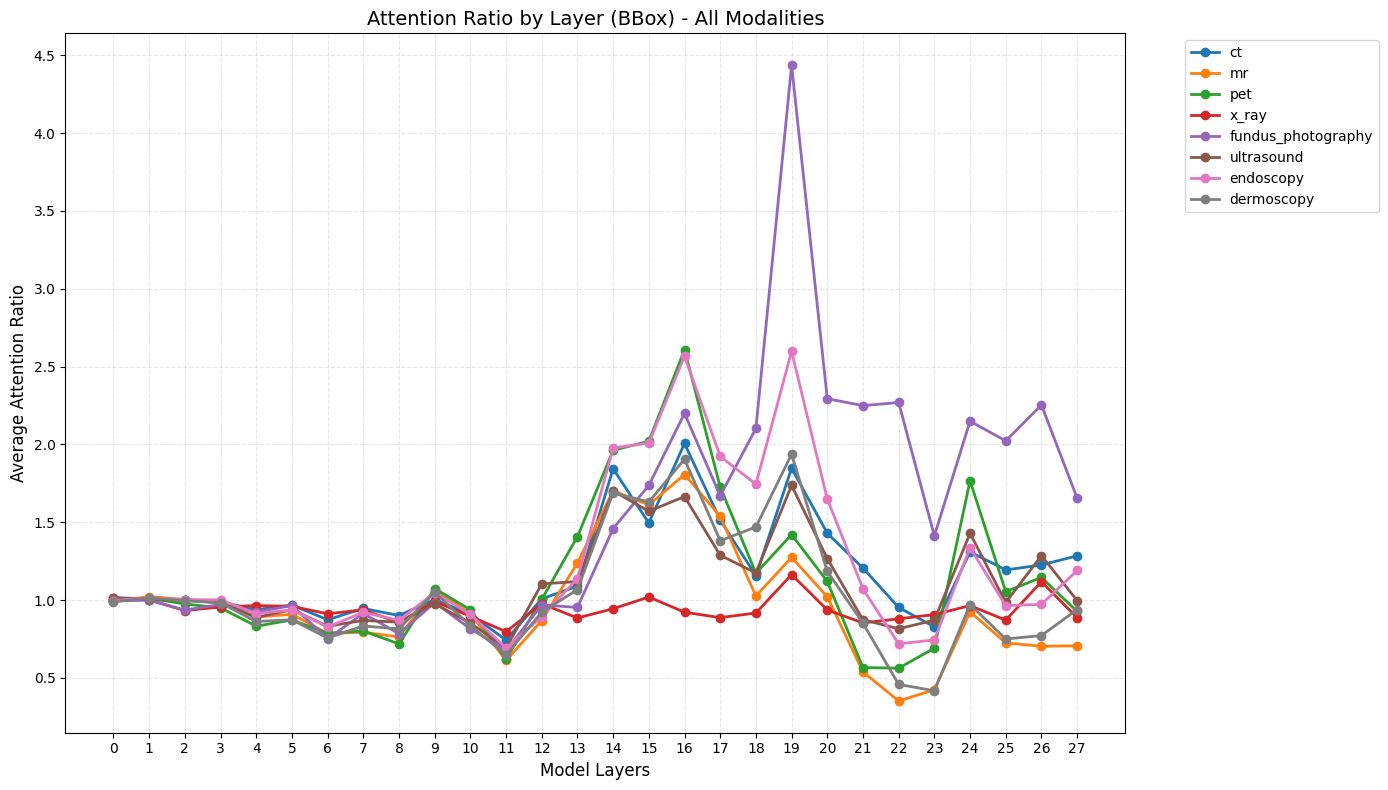

In [4]:
# Load bbox results for all modalities
bbox_modalities = ['ct', 'mr', 'pet', 'x_ray', 'fundus_photography', 'ultrasound', 'endoscopy', 'dermoscopy']
bbox_ratios_by_modality = {}

for modality in bbox_modalities:
    try:
        ratios = np.load(f"./results/layer/bbox/attention_ratios_{modality}.npy")
        bbox_ratios_by_modality[modality] = ratios.mean(axis=0)
    except FileNotFoundError:
        print(f"File not found for modality: {modality}")

# Plot attention ratios by layer for all modalities
plt.figure(figsize=(14, 8))

for modality, layer_ratios in bbox_ratios_by_modality.items():
    plt.plot(range(28), layer_ratios, marker='o', linewidth=2, label=modality)

plt.title("Attention Ratio by Layer (BBox) - All Modalities", fontsize=14)
plt.xlabel("Model Layers", fontsize=12)
plt.ylabel("Average Attention Ratio", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(range(28))
plt.tight_layout()
plt.show()

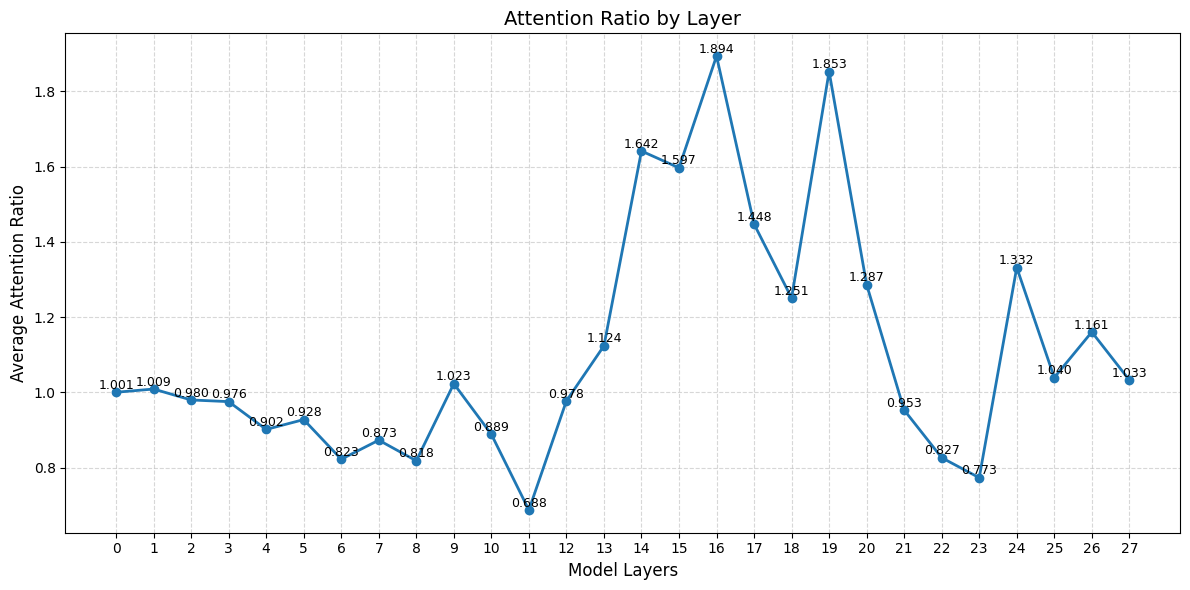

In [9]:
# Load bbox results for all modalities and compute average
bbox_modalities = ['ct', 'mr', 'pet', 'x_ray', 'fundus_photography', 'ultrasound', 'endoscopy', 'dermoscopy']
all_modalities_ratios = []

for modality in bbox_modalities:
    try:
        ratios = np.load(f"./results/layer/bbox/attention_ratios_{modality}.npy")
        all_modalities_ratios.append(ratios)
    except FileNotFoundError:
        print(f"File not found for modality: {modality}")

# Compute average across all modalities
all_modalities_avg = np.concatenate(all_modalities_ratios).mean(axis=0)

plt.figure(figsize=(12, 6))
plt.plot(range(28), all_modalities_avg, marker='o', linewidth=2)

# Add data labels to each point
for x, y in zip(range(28), all_modalities_avg):
    plt.text(x, y+0.001, f"{y:.3f}", ha='center', va='bottom', fontsize=9)

# Titles and labels
plt.title("Attention Ratio by Layer", fontsize=14)
plt.xlabel("Model Layers", fontsize=12)
plt.ylabel("Average Attention Ratio", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.xticks(range(28))
plt.tight_layout()
plt.show()

##### KL Divergence

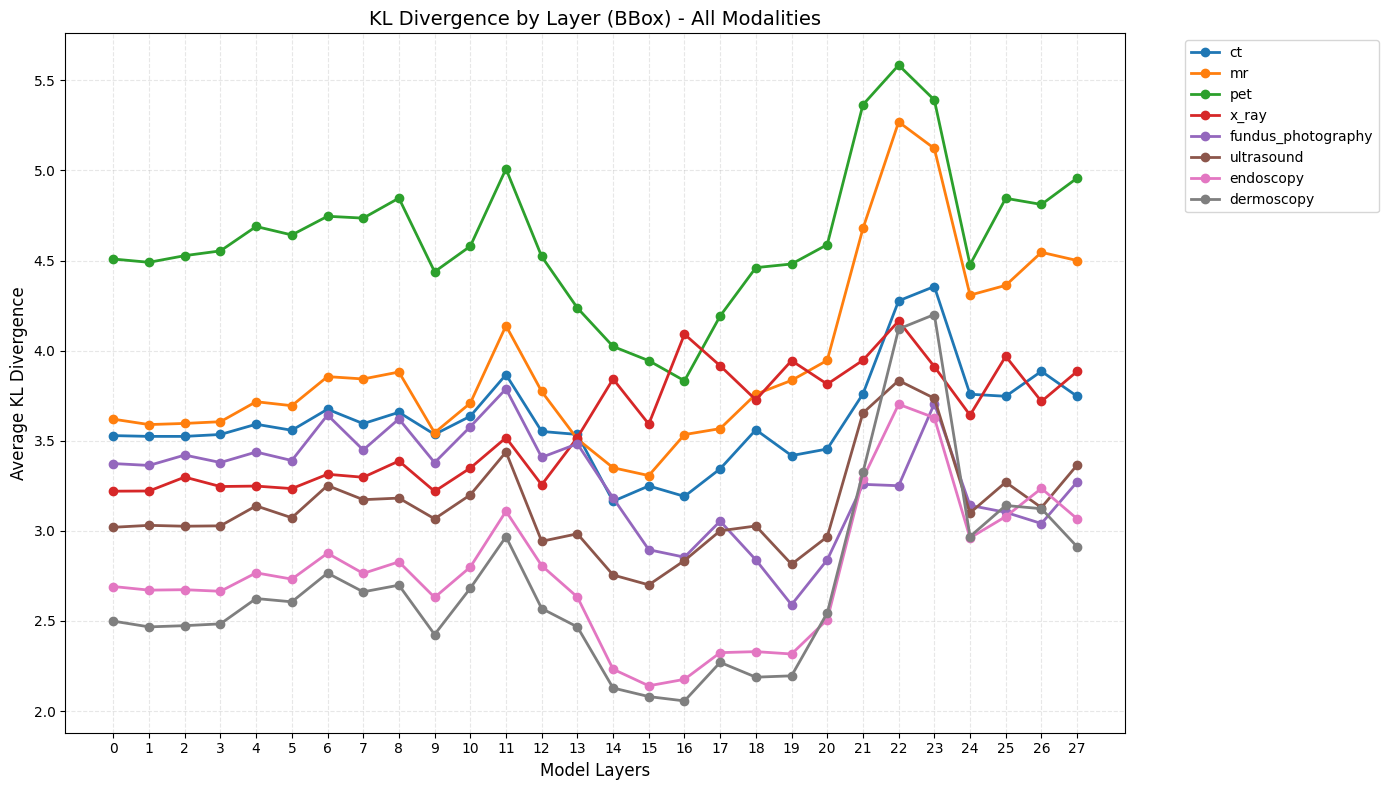

In [10]:
# Load bbox results for all modalities
bbox_modalities = ['ct', 'mr', 'pet', 'x_ray', 'fundus_photography', 'ultrasound', 'endoscopy', 'dermoscopy']
bbox_ratios_by_modality = {}

for modality in bbox_modalities:
    try:
        ratios = np.load(f"./results/layer/bbox/attention_kl_{modality}.npy")
        bbox_ratios_by_modality[modality] = ratios.mean(axis=0)
    except FileNotFoundError:
        print(f"File not found for modality: {modality}")

# Plot attention ratios by layer for all modalities
plt.figure(figsize=(14, 8))

for modality, layer_ratios in bbox_ratios_by_modality.items():
    plt.plot(range(28), layer_ratios, marker='o', linewidth=2, label=modality)

plt.title("KL Divergence by Layer (BBox) - All Modalities", fontsize=14)
plt.xlabel("Model Layers", fontsize=12)
plt.ylabel("Average KL Divergence", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(range(28))
plt.tight_layout()
plt.show()

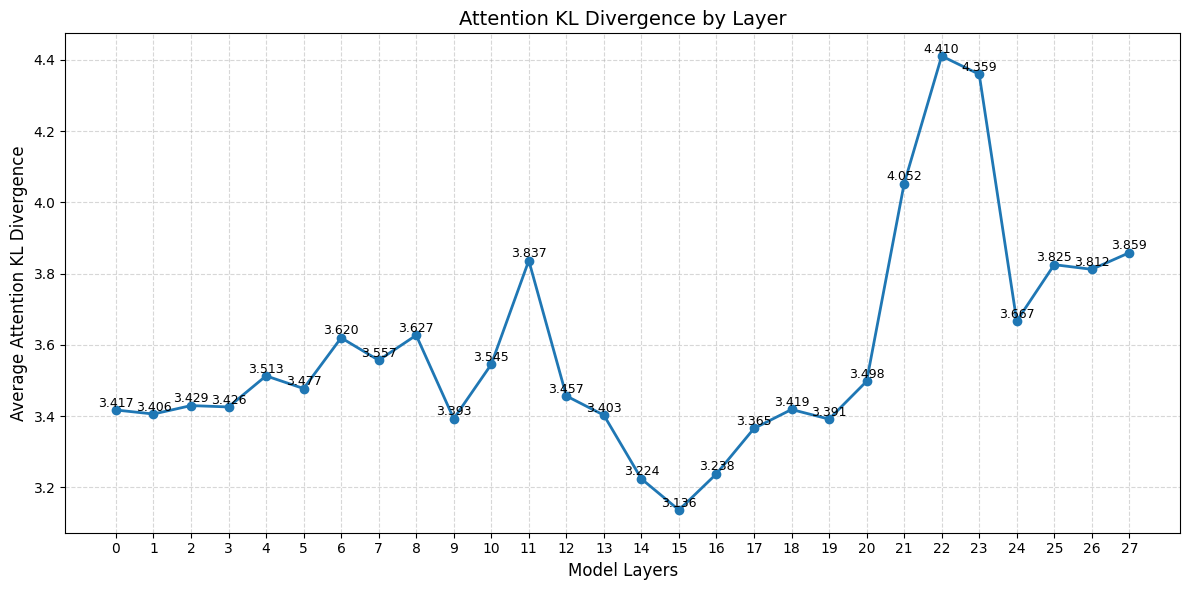

In [11]:
# Load bbox results for all modalities and compute average
bbox_modalities = ['ct', 'mr', 'pet', 'x_ray', 'fundus_photography', 'ultrasound', 'endoscopy', 'dermoscopy']
all_modalities_ratios = []

for modality in bbox_modalities:
    try:
        ratios = np.load(f"./results/layer/bbox/attention_kl_{modality}.npy")
        all_modalities_ratios.append(ratios)
    except FileNotFoundError:
        print(f"File not found for modality: {modality}")

# Compute average across all modalities
all_modalities_avg = np.concatenate(all_modalities_ratios).mean(axis=0)

plt.figure(figsize=(12, 6))
plt.plot(range(28), all_modalities_avg, marker='o', linewidth=2)

# Add data labels to each point
for x, y in zip(range(28), all_modalities_avg):
    plt.text(x, y+0.001, f"{y:.3f}", ha='center', va='bottom', fontsize=9)

# Titles and labels
plt.title("Attention KL Divergence by Layer", fontsize=14)
plt.xlabel("Model Layers", fontsize=12)
plt.ylabel("Average Attention KL Divergence", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.xticks(range(28))
plt.tight_layout()
plt.show()

##### JS Divergence

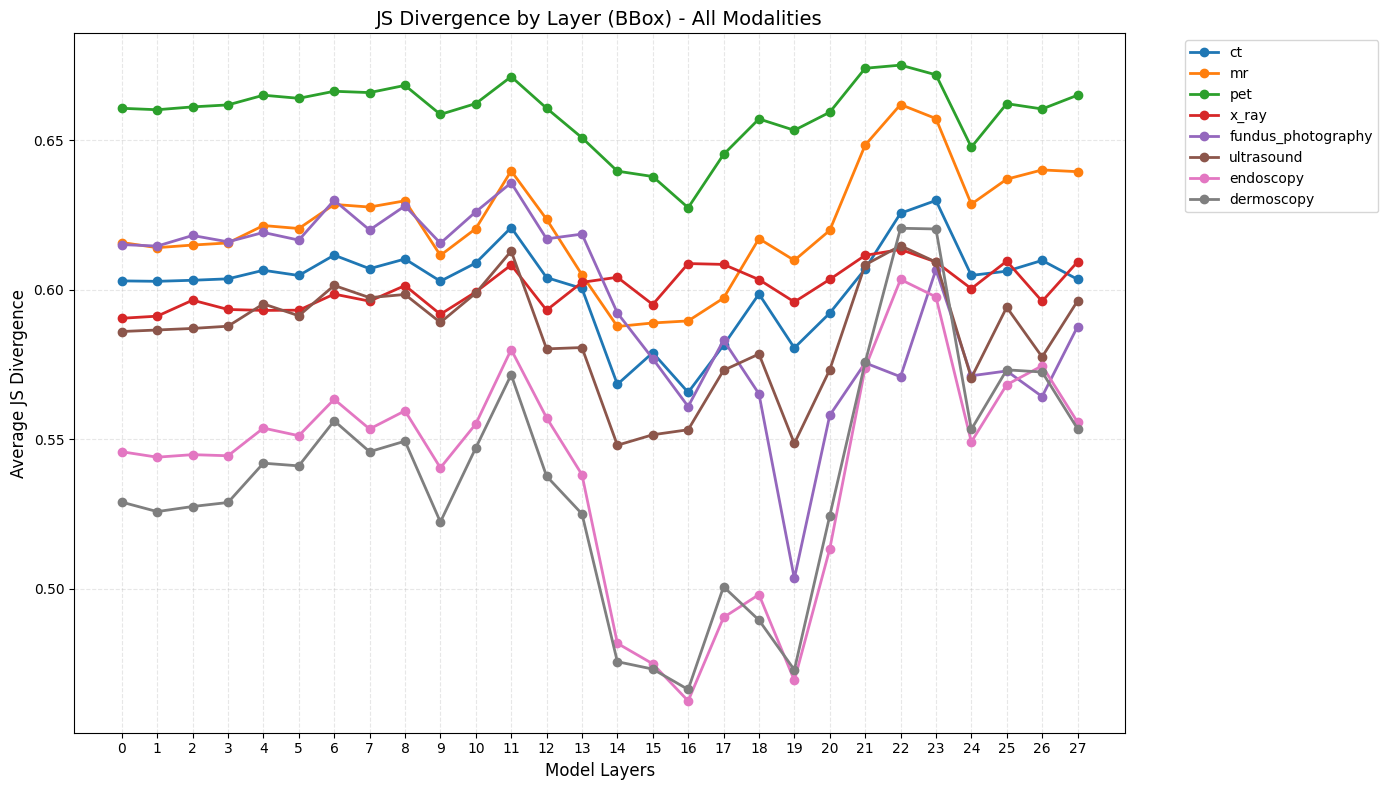

In [12]:
# Load bbox results for all modalities
bbox_modalities = ['ct', 'mr', 'pet', 'x_ray', 'fundus_photography', 'ultrasound', 'endoscopy', 'dermoscopy']
bbox_ratios_by_modality = {}

for modality in bbox_modalities:
    try:
        ratios = np.load(f"./results/layer/bbox/attention_js_{modality}.npy")
        bbox_ratios_by_modality[modality] = ratios.mean(axis=0)
    except FileNotFoundError:
        print(f"File not found for modality: {modality}")

# Plot attention ratios by layer for all modalities
plt.figure(figsize=(14, 8))

for modality, layer_ratios in bbox_ratios_by_modality.items():
    plt.plot(range(28), layer_ratios, marker='o', linewidth=2, label=modality)

plt.title("JS Divergence by Layer (BBox) - All Modalities", fontsize=14)
plt.xlabel("Model Layers", fontsize=12)
plt.ylabel("Average JS Divergence", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(range(28))
plt.tight_layout()
plt.show()

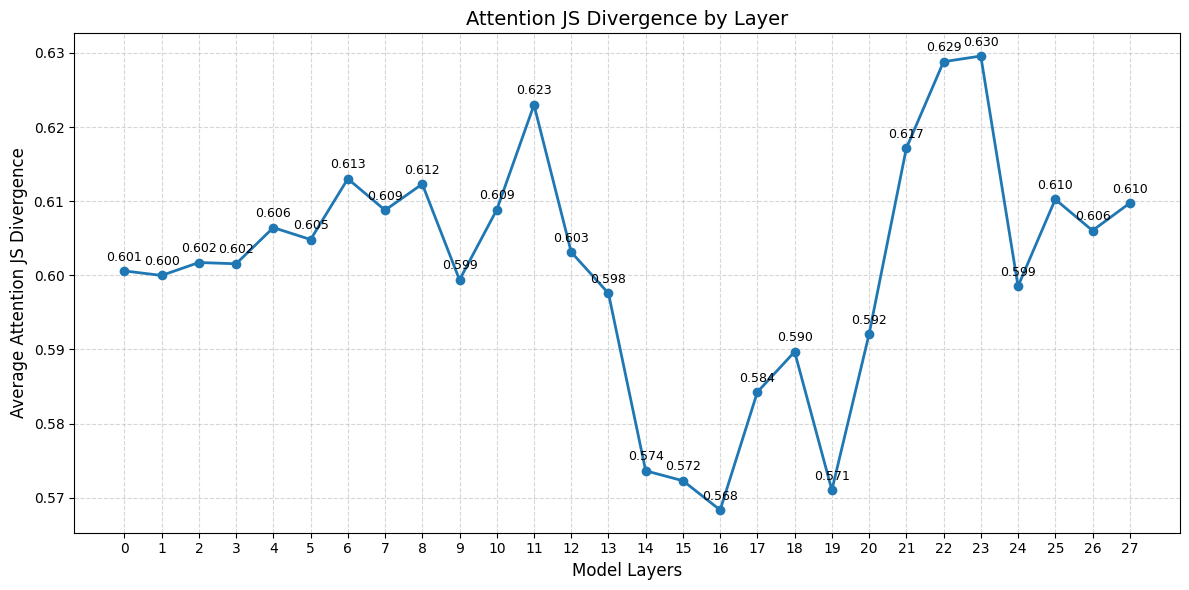

In [13]:
# Load bbox results for all modalities and compute average
bbox_modalities = ['ct', 'mr', 'pet', 'x_ray', 'fundus_photography', 'ultrasound', 'endoscopy', 'dermoscopy']
all_modalities_ratios = []

for modality in bbox_modalities:
    try:
        ratios = np.load(f"./results/layer/bbox/attention_js_{modality}.npy")
        all_modalities_ratios.append(ratios)
    except FileNotFoundError:
        print(f"File not found for modality: {modality}")

# Compute average across all modalities
all_modalities_avg = np.concatenate(all_modalities_ratios).mean(axis=0)

plt.figure(figsize=(12, 6))
plt.plot(range(28), all_modalities_avg, marker='o', linewidth=2)

# Add data labels to each point
for x, y in zip(range(28), all_modalities_avg):
    plt.text(x, y+0.001, f"{y:.3f}", ha='center', va='bottom', fontsize=9)

# Titles and labels
plt.title("Attention JS Divergence by Layer", fontsize=14)
plt.xlabel("Model Layers", fontsize=12)
plt.ylabel("Average Attention JS Divergence", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.xticks(range(28))
plt.tight_layout()
plt.show()

### Mask

##### Attention Ratio

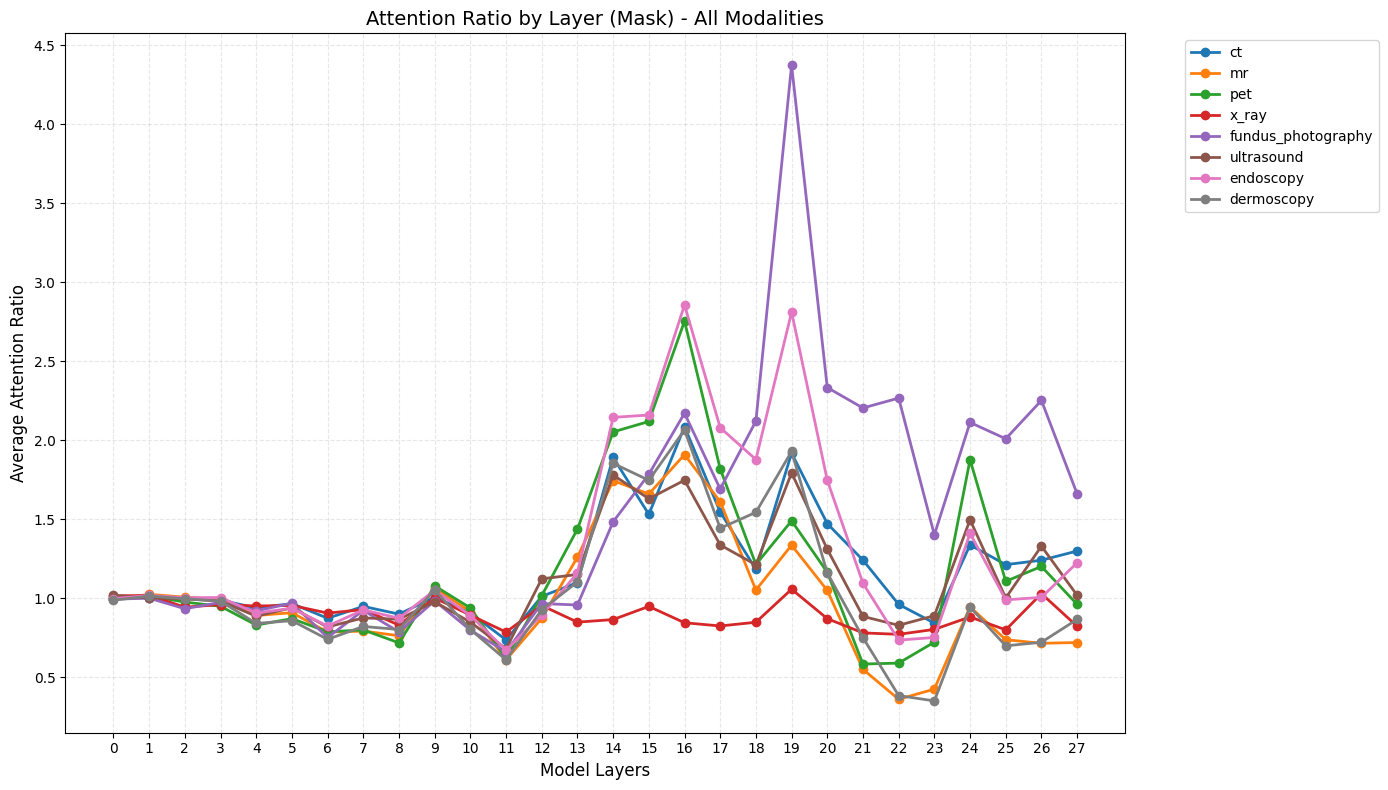

In [14]:
# Load bbox results for all modalities
bbox_modalities = ['ct', 'mr', 'pet', 'x_ray', 'fundus_photography', 'ultrasound', 'endoscopy', 'dermoscopy']
bbox_ratios_by_modality = {}

for modality in bbox_modalities:
    try:
        ratios = np.load(f"./results/layer/mask/attention_ratios_{modality}.npy")
        bbox_ratios_by_modality[modality] = ratios.mean(axis=0)
    except FileNotFoundError:
        print(f"File not found for modality: {modality}")

# Plot attention ratios by layer for all modalities
plt.figure(figsize=(14, 8))

for modality, layer_ratios in bbox_ratios_by_modality.items():
    plt.plot(range(28), layer_ratios, marker='o', linewidth=2, label=modality)

plt.title("Attention Ratio by Layer (Mask) - All Modalities", fontsize=14)
plt.xlabel("Model Layers", fontsize=12)
plt.ylabel("Average Attention Ratio", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(range(28))
plt.tight_layout()
plt.show()

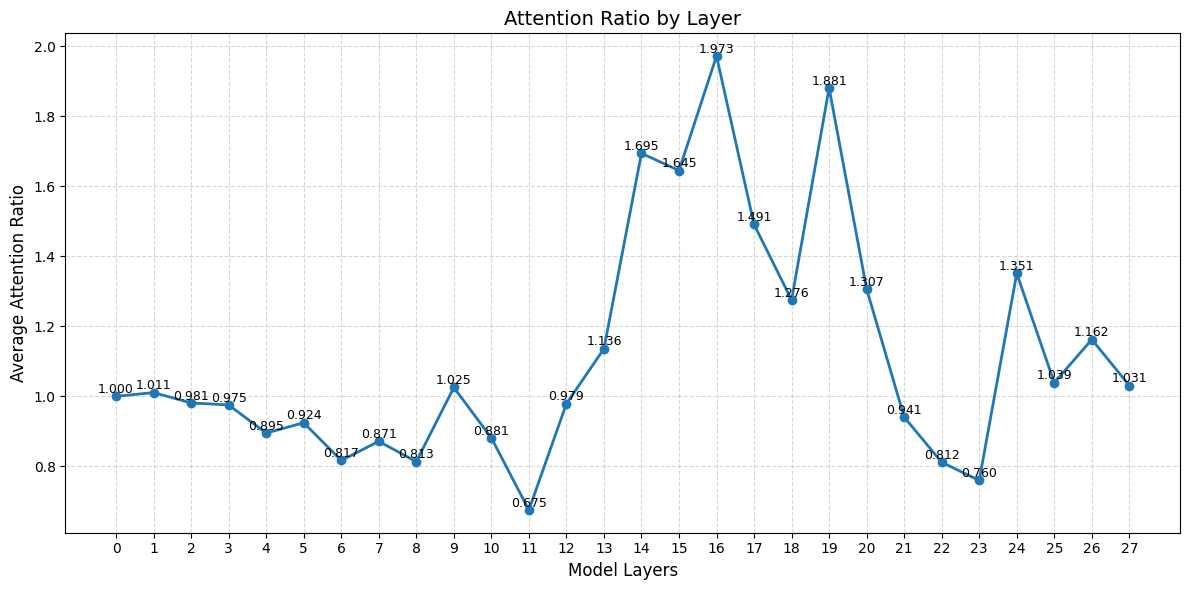

In [15]:
# Load bbox results for all modalities and compute average
bbox_modalities = ['ct', 'mr', 'pet', 'x_ray', 'fundus_photography', 'ultrasound', 'endoscopy', 'dermoscopy']
all_modalities_ratios = []

for modality in bbox_modalities:
    try:
        ratios = np.load(f"./results/layer/mask/attention_ratios_{modality}.npy")
        all_modalities_ratios.append(ratios)
    except FileNotFoundError:
        print(f"File not found for modality: {modality}")

# Compute average across all modalities
all_modalities_avg = np.concatenate(all_modalities_ratios).mean(axis=0)

plt.figure(figsize=(12, 6))
plt.plot(range(28), all_modalities_avg, marker='o', linewidth=2)

# Add data labels to each point
for x, y in zip(range(28), all_modalities_avg):
    plt.text(x, y+0.001, f"{y:.3f}", ha='center', va='bottom', fontsize=9)

# Titles and labels
plt.title("Attention Ratio by Layer", fontsize=14)
plt.xlabel("Model Layers", fontsize=12)
plt.ylabel("Average Attention Ratio", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.xticks(range(28))
plt.tight_layout()
plt.show()

##### KL Divergence

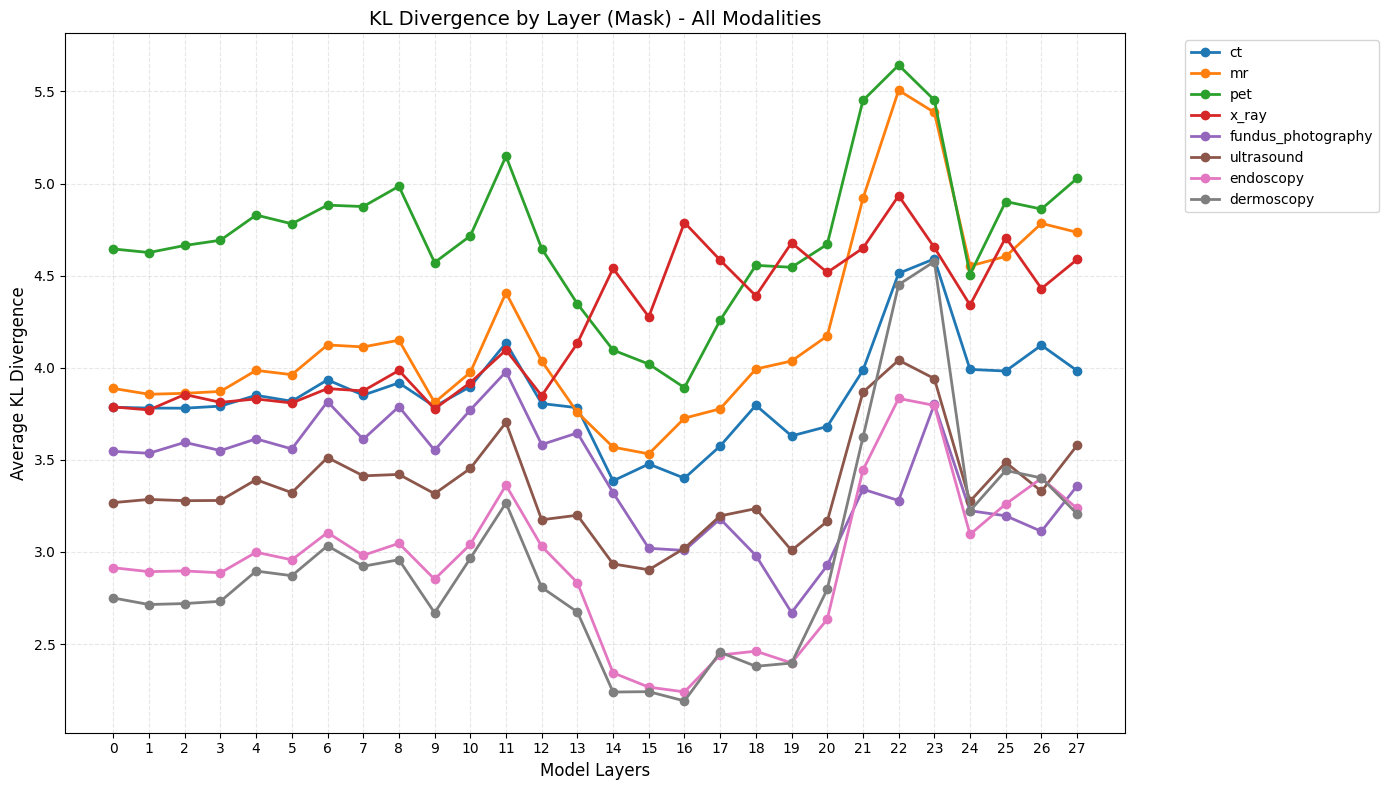

In [16]:
# Load bbox results for all modalities
bbox_modalities = ['ct', 'mr', 'pet', 'x_ray', 'fundus_photography', 'ultrasound', 'endoscopy', 'dermoscopy']
bbox_ratios_by_modality = {}

for modality in bbox_modalities:
    try:
        ratios = np.load(f"./results/layer/mask/attention_kl_{modality}.npy")
        bbox_ratios_by_modality[modality] = ratios.mean(axis=0)
    except FileNotFoundError:
        print(f"File not found for modality: {modality}")

# Plot attention ratios by layer for all modalities
plt.figure(figsize=(14, 8))

for modality, layer_ratios in bbox_ratios_by_modality.items():
    plt.plot(range(28), layer_ratios, marker='o', linewidth=2, label=modality)

plt.title("KL Divergence by Layer (Mask) - All Modalities", fontsize=14)
plt.xlabel("Model Layers", fontsize=12)
plt.ylabel("Average KL Divergence", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(range(28))
plt.tight_layout()
plt.show()

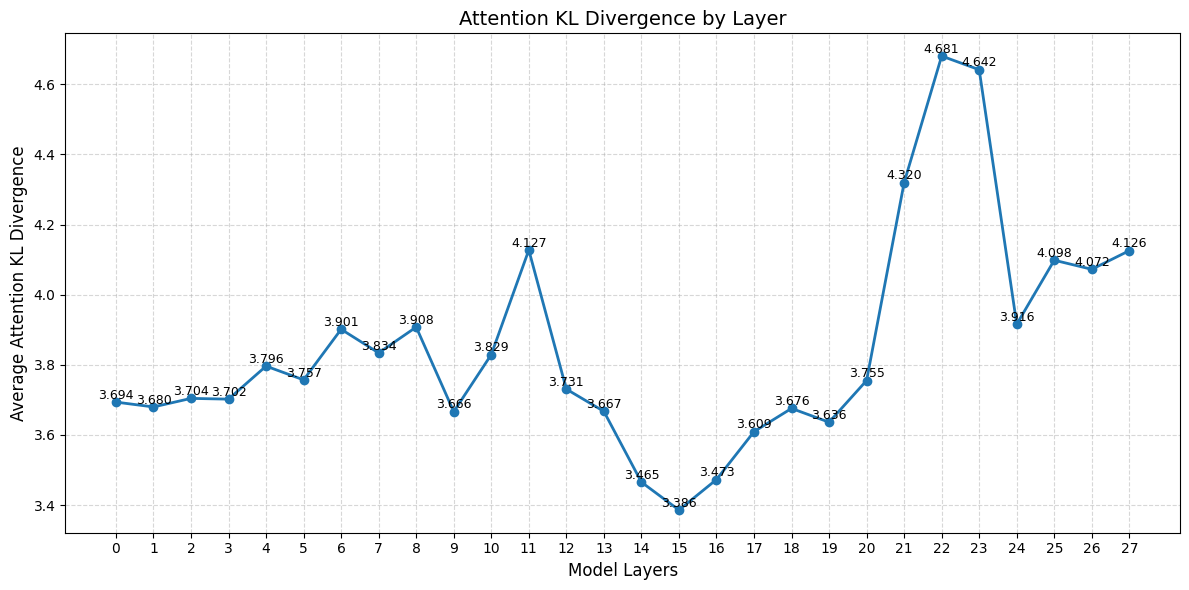

In [17]:
# Load bbox results for all modalities and compute average
bbox_modalities = ['ct', 'mr', 'pet', 'x_ray', 'fundus_photography', 'ultrasound', 'endoscopy', 'dermoscopy']
all_modalities_ratios = []

for modality in bbox_modalities:
    try:
        ratios = np.load(f"./results/layer/mask/attention_kl_{modality}.npy")
        all_modalities_ratios.append(ratios)
    except FileNotFoundError:
        print(f"File not found for modality: {modality}")

# Compute average across all modalities
all_modalities_avg = np.concatenate(all_modalities_ratios).mean(axis=0)

plt.figure(figsize=(12, 6))
plt.plot(range(28), all_modalities_avg, marker='o', linewidth=2)

# Add data labels to each point
for x, y in zip(range(28), all_modalities_avg):
    plt.text(x, y+0.001, f"{y:.3f}", ha='center', va='bottom', fontsize=9)

# Titles and labels
plt.title("Attention KL Divergence by Layer", fontsize=14)
plt.xlabel("Model Layers", fontsize=12)
plt.ylabel("Average Attention KL Divergence", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.xticks(range(28))
plt.tight_layout()
plt.show()

##### JS Divergence

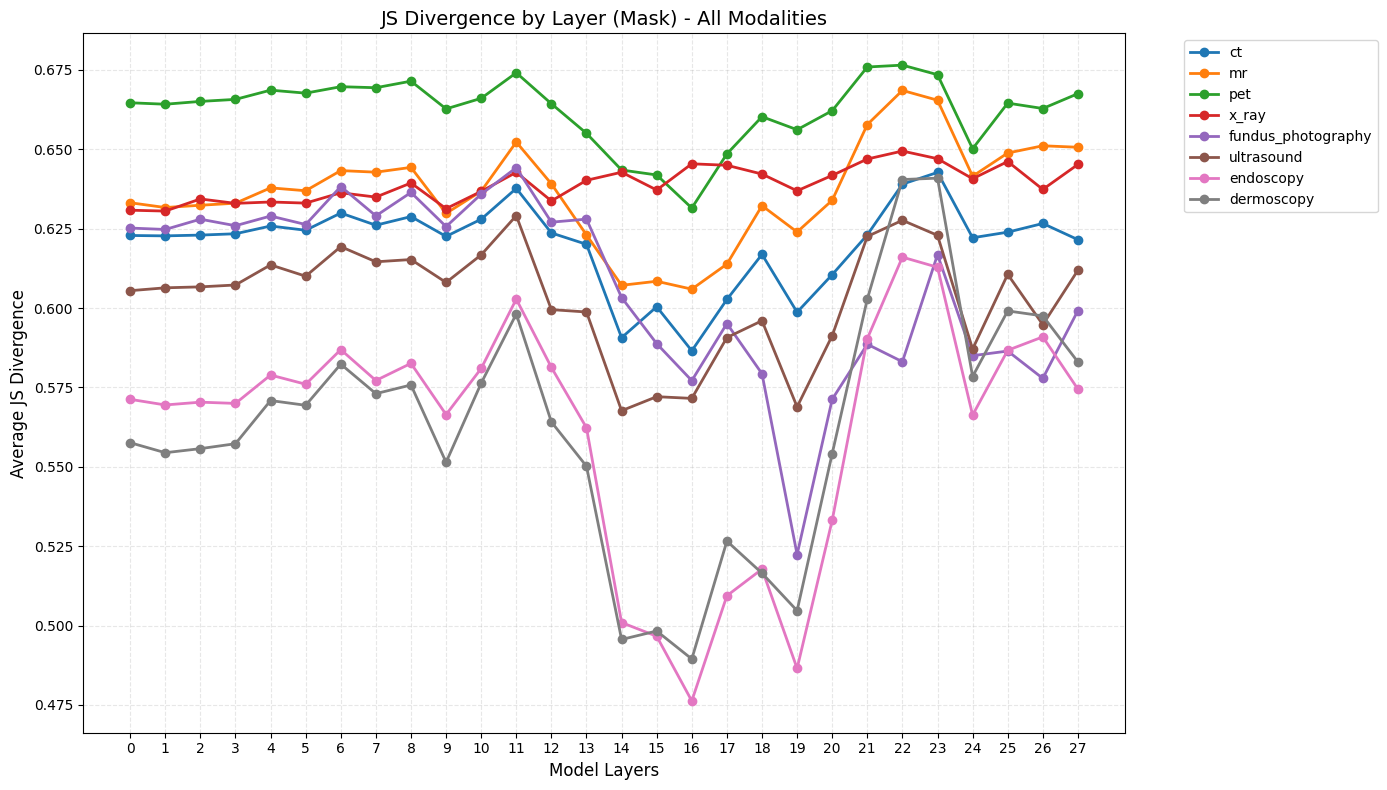

In [18]:
# Load bbox results for all modalities
bbox_modalities = ['ct', 'mr', 'pet', 'x_ray', 'fundus_photography', 'ultrasound', 'endoscopy', 'dermoscopy']
bbox_ratios_by_modality = {}

for modality in bbox_modalities:
    try:
        ratios = np.load(f"./results/layer/mask/attention_js_{modality}.npy")
        bbox_ratios_by_modality[modality] = ratios.mean(axis=0)
    except FileNotFoundError:
        print(f"File not found for modality: {modality}")

# Plot attention ratios by layer for all modalities
plt.figure(figsize=(14, 8))

for modality, layer_ratios in bbox_ratios_by_modality.items():
    plt.plot(range(28), layer_ratios, marker='o', linewidth=2, label=modality)

plt.title("JS Divergence by Layer (Mask) - All Modalities", fontsize=14)
plt.xlabel("Model Layers", fontsize=12)
plt.ylabel("Average JS Divergence", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(range(28))
plt.tight_layout()
plt.show()

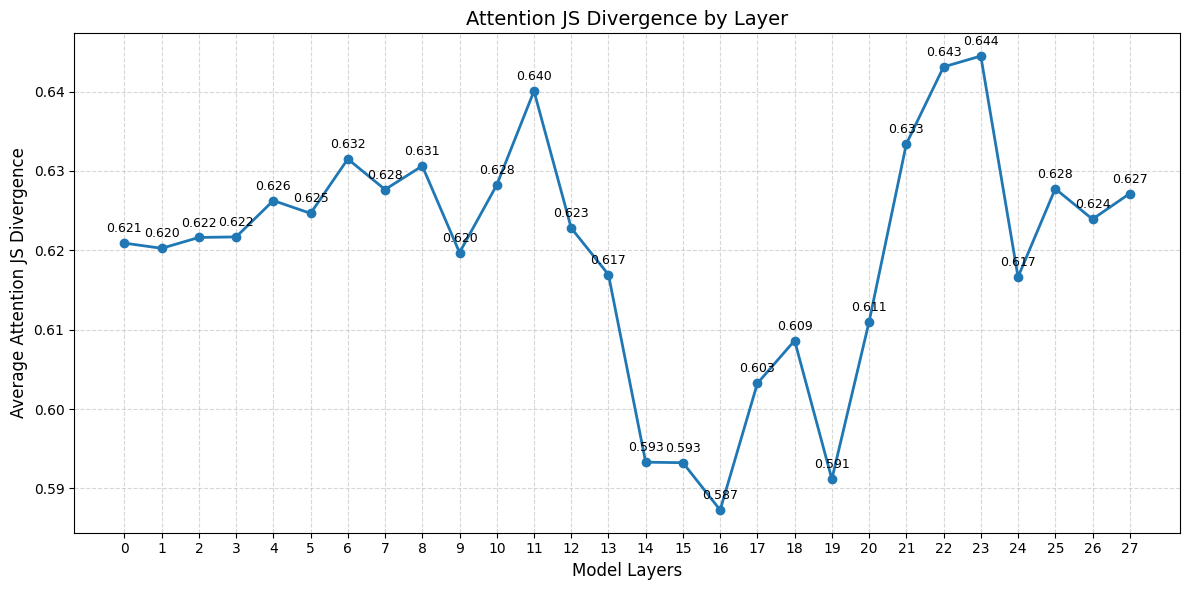

In [19]:
# Load bbox results for all modalities and compute average
bbox_modalities = ['ct', 'mr', 'pet', 'x_ray', 'fundus_photography', 'ultrasound', 'endoscopy', 'dermoscopy']
all_modalities_ratios = []

for modality in bbox_modalities:
    try:
        ratios = np.load(f"./results/layer/mask/attention_js_{modality}.npy")
        all_modalities_ratios.append(ratios)
    except FileNotFoundError:
        print(f"File not found for modality: {modality}")

# Compute average across all modalities
all_modalities_avg = np.concatenate(all_modalities_ratios).mean(axis=0)

plt.figure(figsize=(12, 6))
plt.plot(range(28), all_modalities_avg, marker='o', linewidth=2)

# Add data labels to each point
for x, y in zip(range(28), all_modalities_avg):
    plt.text(x, y+0.001, f"{y:.3f}", ha='center', va='bottom', fontsize=9)

# Titles and labels
plt.title("Attention JS Divergence by Layer", fontsize=14)
plt.xlabel("Model Layers", fontsize=12)
plt.ylabel("Average Attention JS Divergence", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.xticks(range(28))
plt.tight_layout()
plt.show()

# COCO Results

In [27]:
attention_ratios_normalized = []
attention_kl_normalized = []
attention_js_normalized = []

questions = []
input_path = "./COCO.jsonl"
data_path = "/home/tianze/MLLM/HuatuoGPT-Vision/val2014"
with open(input_path, "r") as infile:
    for line in infile:
        questions.append(json.loads(line))


for sample in tqdm(questions):
    image_path = os.path.join(data_path, sample["image"])
    qs = f"Is there a {sample['label']} in the image?"
    att_maps, general_att_maps = generate_attention_maps(qs, image_path)
    gt_tokens = sample["gt_tokens"]

    att_ratio_normalized = attention_ratio_vectorized(att_maps/general_att_maps, gt_tokens)
    att_kl_normalized = kl_divergence_vectorized(att_maps/general_att_maps, gt_tokens)
    att_js_normalized = js_divergence_vectorized(att_maps/general_att_maps, gt_tokens)

    attention_ratios_normalized.append(att_ratio_normalized)
    attention_kl_normalized.append(att_kl_normalized)
    attention_js_normalized.append(att_js_normalized)


os.makedirs("./results/layer_coco/", exist_ok=True)
np.save(f"./results/layer_coco/attention_ratios.npy", np.array(attention_ratios_normalized))
np.save(f"./results/layer_coco/attention_kl.npy", np.array(attention_kl_normalized))
np.save(f"./results/layer_coco/attention_js.npy", np.array(attention_js_normalized))

100%|██████████| 2000/2000 [12:38<00:00,  2.64it/s]


##### Attention Ratio

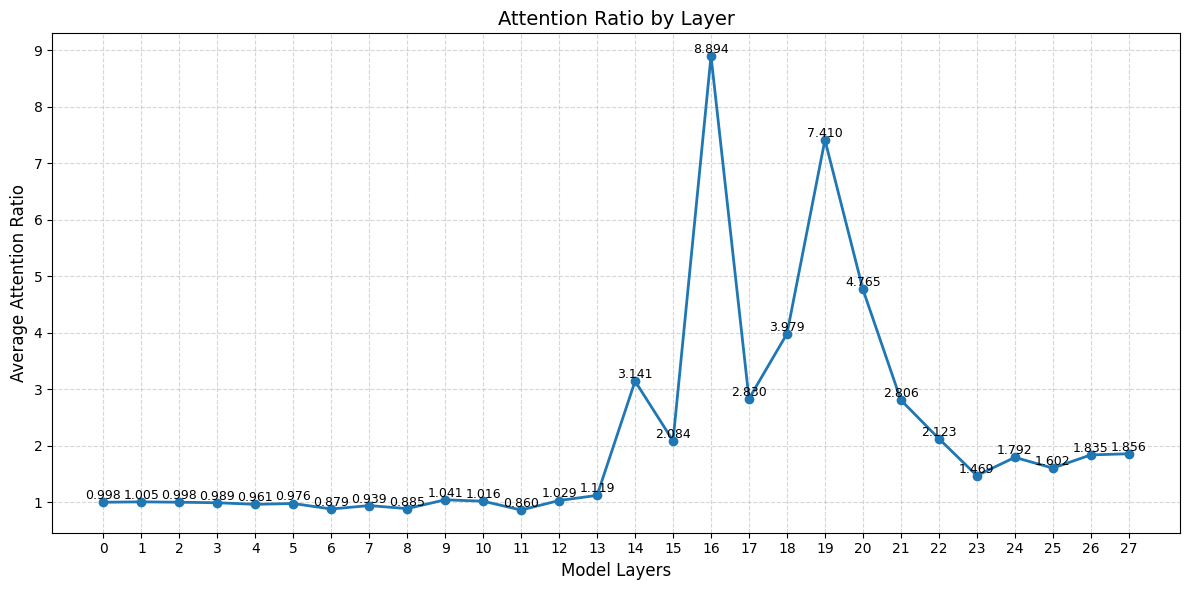

In [28]:
layer_ratios = np.array(attention_ratios_normalized).mean(axis=0)

plt.figure(figsize=(12, 6))
plt.plot(range(28), layer_ratios, marker='o', linewidth=2)

# Add data labels to each point
for x, y in zip(range(28), layer_ratios):
    plt.text(x, y+0.001, f"{y:.3f}", ha='center', va='bottom', fontsize=9)

# Titles and labels
plt.title("Attention Ratio by Layer", fontsize=14)
plt.xlabel("Model Layers", fontsize=12)
plt.ylabel("Average Attention Ratio", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.xticks(range(28))
plt.tight_layout()
plt.show()

##### KL Divergence

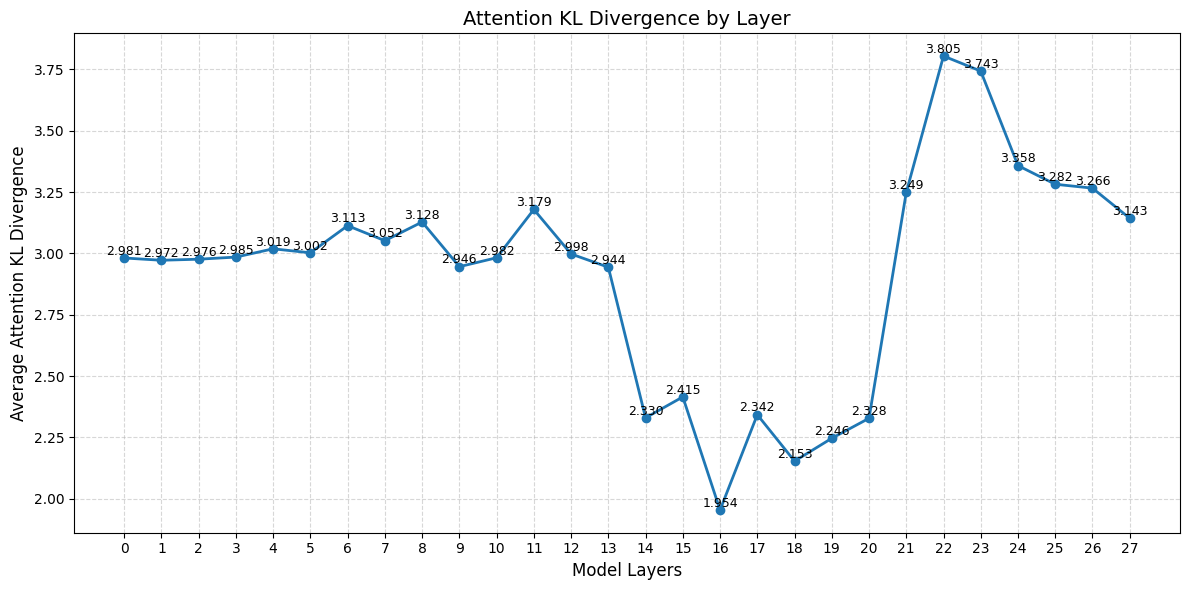

In [29]:
layer_ratios = np.array(attention_kl_normalized).mean(axis=0)

plt.figure(figsize=(12, 6))
plt.plot(range(28), layer_ratios, marker='o', linewidth=2)

# Add data labels to each point
for x, y in zip(range(28), layer_ratios):
    plt.text(x, y+0.001, f"{y:.3f}", ha='center', va='bottom', fontsize=9)

# Titles and labels
plt.title("Attention KL Divergence by Layer", fontsize=14)
plt.xlabel("Model Layers", fontsize=12)
plt.ylabel("Average Attention KL Divergence", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.xticks(range(28))
plt.tight_layout()
plt.show()

##### JS Divergence

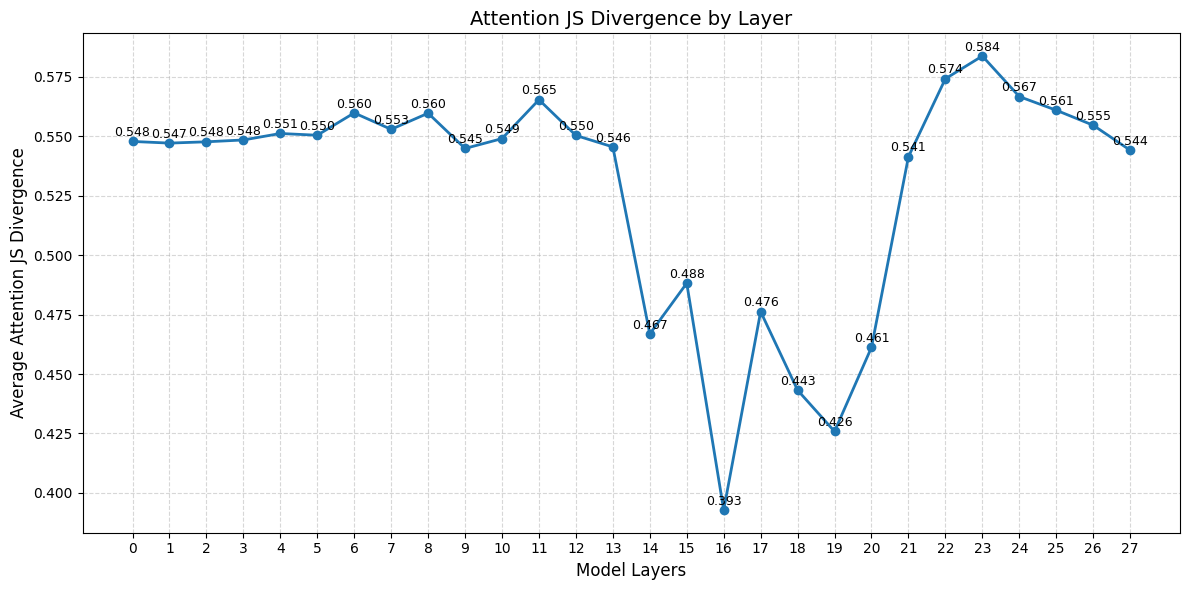

In [30]:
layer_ratios = np.array(attention_js_normalized).mean(axis=0)

plt.figure(figsize=(12, 6))
plt.plot(range(28), layer_ratios, marker='o', linewidth=2)

# Add data labels to each point
for x, y in zip(range(28), layer_ratios):
    plt.text(x, y+0.001, f"{y:.3f}", ha='center', va='bottom', fontsize=9)

# Titles and labels
plt.title("Attention JS Divergence by Layer", fontsize=14)
plt.xlabel("Model Layers", fontsize=12)
plt.ylabel("Average Attention JS Divergence", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.xticks(range(28))
plt.tight_layout()
plt.show()

# Get vision-centric attention heads

In [4]:
attention_ratios_normalized = []
attention_kl_normalized = []
attention_js_normalized = []

questions = []
input_path = "/home/tianze/Datasets/VGMED/VGMED_localization.jsonl"
data_path = "/home/tianze/Datasets/VGMED/"
with open(input_path, "r") as infile:
    for line in infile:
        questions.append(json.loads(line))


for sample in tqdm(questions):
    image_path = os.path.join(data_path, sample["image"])
    qs = sample["question"]
    att_maps, general_att_maps = generate_attention_maps_per_head(qs, image_path)
    general_att_maps = np.expand_dims(general_att_maps, axis=1)
    gt_tokens = sample["gt_tokens_huatuo"]

    att_ratio_normalized = attention_ratio_vectorized(att_maps/general_att_maps, gt_tokens)
    att_kl_normalized = kl_divergence_vectorized(att_maps/general_att_maps, gt_tokens)
    att_js_normalized = js_divergence_vectorized(att_maps/general_att_maps, gt_tokens)

    attention_ratios_normalized.append(att_ratio_normalized)
    attention_kl_normalized.append(att_kl_normalized)
    attention_js_normalized.append(att_js_normalized)


# os.makedirs("./results/head_coco_34B/", exist_ok=True)
# np.save(f"./results/head_coco_34B/attention_ratios.npy", np.array(attention_ratios_normalized))
# np.save(f"./results/head_coco_34B/attention_kl.npy", np.array(attention_kl_normalized))
# np.save(f"./results/head_coco_34B/attention_js.npy", np.array(attention_js_normalized))

os.makedirs("./results/head_vgmed_7B/", exist_ok=True)
np.save(f"./results/head_vgmed_7B/attention_ratios.npy", np.array(attention_ratios_normalized))
np.save(f"./results/head_vgmed_7B/attention_kl.npy", np.array(attention_kl_normalized))
np.save(f"./results/head_vgmed_7B/attention_js.npy", np.array(attention_js_normalized))

100%|██████████| 13962/13962 [1:57:56<00:00,  1.97it/s]  


In [18]:
from scipy.stats import spearmanr, kendalltau

attention_js_normalized = np.load("./results/head_coco_7B/attention_js.npy")
attention_kl_normalized = np.load("./results/head_coco_7B/attention_kl.npy")
attention_ratios_normalized = np.load("./results/head_coco_7B/attention_ratios.npy")

# Compute mean across samples for each metric
mean_ratios = np.array(attention_ratios_normalized).mean(axis=0)
mean_kl = np.array(attention_kl_normalized).mean(axis=0)
mean_js = np.array(attention_js_normalized).mean(axis=0)

# Flatten the matrices to get 1D arrays for correlation analysis
vgmed_ratios_flat = mean_ratios.flatten()
vgmed_kl_flat = mean_kl.flatten()
vgmed_js_flat = mean_js.flatten()

# Compute Spearman correlations (rank-based correlations)
spearman_ratio_kl = -spearmanr(vgmed_ratios_flat, vgmed_kl_flat)[0]
spearman_ratio_js = -spearmanr(vgmed_ratios_flat, vgmed_js_flat)[0]
spearman_kl_js = spearmanr(vgmed_kl_flat, vgmed_js_flat)[0]

# Compute Kendall correlations (rank-based correlations)
kendall_ratio_kl = -kendalltau(vgmed_ratios_flat, vgmed_kl_flat)[0]
kendall_ratio_js = -kendalltau(vgmed_ratios_flat, vgmed_js_flat)[0]
kendall_kl_js = kendalltau(vgmed_kl_flat, vgmed_js_flat)[0]

print("Spearman Correlations:")
print(f"Attention Ratio and KL Divergence: {spearman_ratio_kl:.4f}")
print(f"Attention Ratio and JS Divergence: {spearman_ratio_js:.4f}")
print(f"KL Divergence and JS Divergence: {spearman_kl_js:.4f}")

print("\nKendall Correlations:")
print(f"Attention Ratio and KL Divergence: {kendall_ratio_kl:.4f}")
print(f"Attention Ratio and JS Divergence: {kendall_ratio_js:.4f}")
print(f"KL Divergence and JS Divergence: {kendall_kl_js:.4f}")

Spearman Correlations:
Attention Ratio and KL Divergence: 0.7332
Attention Ratio and JS Divergence: 0.8222
KL Divergence and JS Divergence: 0.9052

Kendall Correlations:
Attention Ratio and KL Divergence: 0.5482
Attention Ratio and JS Divergence: 0.6694
KL Divergence and JS Divergence: 0.7834


In [7]:
attention_ratios_normalized = []
attention_kl_normalized = []
attention_js_normalized = []

questions = []
input_path = "./COCO.jsonl"
data_path = "/home/tianze/MLLM/HuatuoGPT-Vision/val2014"
with open(input_path, "r") as infile:
    for line in infile:
        questions.append(json.loads(line))

questions = random.sample(questions, 4000)


for sample in tqdm(questions):
    image_path = os.path.join(data_path, sample["image"])
    qs = f"Is there a {sample['label']} in the image?"
    att_maps, general_att_maps = generate_attention_maps_per_head(qs, image_path)
    gt_tokens = sample["gt_tokens"]

    att_ratio_normalized = attention_ratio_vectorized(att_maps/general_att_maps, gt_tokens)
    att_kl_normalized = kl_divergence_vectorized(att_maps/general_att_maps, gt_tokens)
    att_js_normalized = js_divergence_vectorized(att_maps/general_att_maps, gt_tokens)

    attention_ratios_normalized.append(att_ratio_normalized)
    attention_kl_normalized.append(att_kl_normalized)
    attention_js_normalized.append(att_js_normalized)


# os.makedirs("./results/head_coco/", exist_ok=True)
# np.save(f"./results/head_coco/attention_ratios.npy", np.array(attention_ratios_normalized))
# np.save(f"./results/head_coco/attention_kl.npy", np.array(attention_kl_normalized))
# np.save(f"./results/head_coco/attention_js.npy", np.array(attention_js_normalized))

100%|██████████| 4000/4000 [25:23<00:00,  2.63it/s]


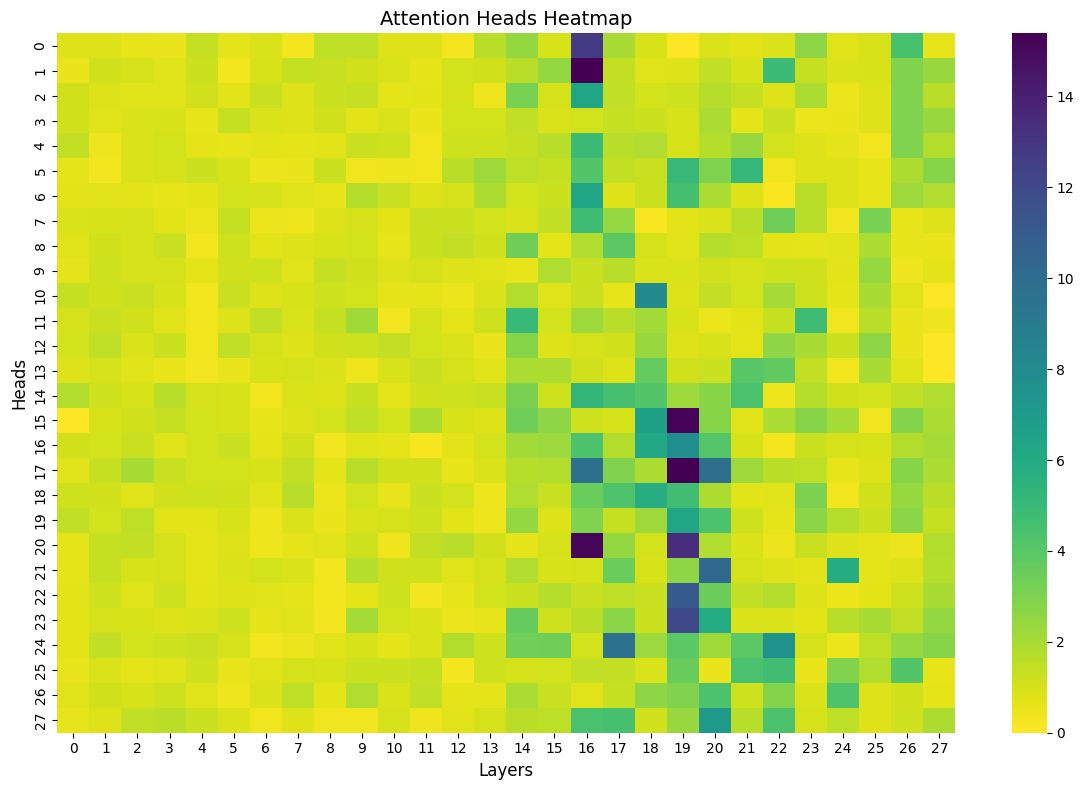

In [21]:
attention_js_normalized = np.load("./results/head_coco_7B/attention_ratios.npy")
head_metric = np.array(attention_js_normalized).mean(axis=0)

# Plot the heatmap for head_ratios
plt.figure(figsize=(12, 8))
sns.heatmap(head_metric.T, annot=False, cmap="viridis_r", cbar=True)

# Titles and labels
plt.title("Attention Heads Heatmap", fontsize=14)
plt.xlabel("Layers", fontsize=12)
plt.ylabel("Heads", fontsize=12)

plt.tight_layout()
plt.savefig("attention_heads_heatmap.pdf", format="pdf")
plt.show()

In [8]:
from scipy.stats import spearmanr, kendalltau

# Compute mean across samples for each metric
mean_ratios = np.array(attention_ratios_normalized).mean(axis=0)
mean_kl = np.array(attention_kl_normalized).mean(axis=0)
mean_js = np.array(attention_js_normalized).mean(axis=0)

# Flatten the matrices to get 1D arrays for correlation analysis
coco_ratios_flat = mean_ratios.flatten()
coco_kl_flat = mean_kl.flatten()
coco_js_flat = mean_js.flatten()

# Compute Spearman correlations (rank-based correlations)
spearman_ratio_kl = -spearmanr(coco_ratios_flat, coco_kl_flat)[0]
spearman_ratio_js = -spearmanr(coco_ratios_flat, coco_js_flat)[0]
spearman_kl_js = spearmanr(coco_kl_flat, coco_js_flat)[0]

# Compute Kendall correlations (rank-based correlations)
kendall_ratio_kl = -kendalltau(coco_ratios_flat, coco_kl_flat)[0]
kendall_ratio_js = -kendalltau(coco_ratios_flat, coco_js_flat)[0]
kendall_kl_js = kendalltau(coco_kl_flat, coco_js_flat)[0]

print("Spearman Correlations:")
print(f"Attention Ratio and KL Divergence: {spearman_ratio_kl:.4f}")
print(f"Attention Ratio and JS Divergence: {spearman_ratio_js:.4f}")
print(f"KL Divergence and JS Divergence: {spearman_kl_js:.4f}")

print("\nKendall Correlations:")
print(f"Attention Ratio and KL Divergence: {kendall_ratio_kl:.4f}")
print(f"Attention Ratio and JS Divergence: {kendall_ratio_js:.4f}")
print(f"KL Divergence and JS Divergence: {kendall_kl_js:.4f}")

Spearman Correlations:
Attention Ratio and KL Divergence: 0.8084
Attention Ratio and JS Divergence: 0.8724
KL Divergence and JS Divergence: 0.9075

Kendall Correlations:
Attention Ratio and KL Divergence: 0.6214
Attention Ratio and JS Divergence: 0.7334
KL Divergence and JS Divergence: 0.7861


In [5]:
attention_js_normalized = np.load("./results/head_coco_7B/attention_js.npy")
attention_kl_normalized = np.load("./results/head_coco_7B/attention_kl.npy")
attention_ratios_normalized = np.load("./results/head_coco_7B/attention_ratios.npy")

# Compute mean across samples for each metric
mean_ratios = np.array(attention_ratios_normalized).mean(axis=0)
mean_kl = np.array(attention_kl_normalized).mean(axis=0)
mean_js = np.array(attention_js_normalized).mean(axis=0)

# Flatten the matrices to get 1D arrays for correlation analysis
coco_ratios_flat = mean_ratios.flatten()
coco_kl_flat = mean_kl.flatten()
coco_js_flat = mean_js.flatten()


attention_js_normalized = np.load("./results/head_vgmed_7B/attention_js.npy")
attention_kl_normalized = np.load("./results/head_vgmed_7B/attention_kl.npy")
attention_ratios_normalized = np.load("./results/head_vgmed_7B/attention_ratios.npy")

# Compute mean across samples for each metric
mean_ratios = np.array(attention_ratios_normalized).mean(axis=0)
mean_kl = np.array(attention_kl_normalized).mean(axis=0)
mean_js = np.array(attention_js_normalized).mean(axis=0)

# Flatten the matrices to get 1D arrays for correlation analysis
vgmed_ratios_flat = mean_ratios.flatten()
vgmed_kl_flat = mean_kl.flatten()
vgmed_js_flat = mean_js.flatten()

In [6]:
from scipy.stats import spearmanr, kendalltau

# Compute Spearman correlations (rank-based correlations)
spearman_ratio = spearmanr(coco_ratios_flat, vgmed_ratios_flat)[0]
spearman_kl = spearmanr(coco_kl_flat, vgmed_kl_flat)[0]
spearman_js = spearmanr(coco_js_flat, vgmed_js_flat)[0]

# Compute Kendall correlations (rank-based correlations)
kendall_ratio = kendalltau(coco_ratios_flat, vgmed_ratios_flat)[0]
kendall_kl = kendalltau(coco_kl_flat, vgmed_kl_flat)[0]
kendall_js = kendalltau(coco_js_flat, vgmed_js_flat)[0]

print("Correlations between COCO and VGMED:")
print(f"Attention Ratio - Spearman: {spearman_ratio:.4f}, Kendall: {kendall_ratio:.4f}")
print(f"KL Divergence - Spearman: {spearman_kl:.4f}, Kendall: {kendall_kl:.4f}")
print(f"JS Divergence - Spearman: {spearman_js:.4f}, Kendall: {kendall_js:.4f}")

Correlations between COCO and VGMED:
Attention Ratio - Spearman: 0.7782, Kendall: 0.5909
KL Divergence - Spearman: 0.8801, Kendall: 0.7090
JS Divergence - Spearman: 0.8501, Kendall: 0.6710


In [11]:
# Get the lowest 5 attention heads for each layer
lowest_5_heads_per_layer = []

for layer in range(28):
    layer_values = head_metric[layer]
    # Get indices of lowest 5 values for this layer
    lowest_5_indices = np.argsort(layer_values)[:5]  # Sort ascending, take first 5
    lowest_5_values = layer_values[lowest_5_indices]
    
    lowest_5_heads_per_layer.append({
        'layer': layer,
        'lowest_heads': lowest_5_indices.tolist(),
        'lowest_values': lowest_5_values.tolist()
    })

# Print results
for layer_info in lowest_5_heads_per_layer:
    print(f"Layer {layer_info['layer']:2d}: Heads {layer_info['lowest_heads']} with values {[f'{v:.3f}' for v in layer_info['lowest_values']]}")

Layer  0: Heads [2, 0, 14, 4, 19] with values ['3.891', '3.898', '3.929', '3.932', '4.045']
Layer  1: Heads [1, 21, 9, 14, 18] with values ['3.009', '3.829', '3.882', '3.921', '4.035']
Layer  2: Heads [1, 17, 15, 16, 19] with values ['2.959', '2.988', '3.052', '3.139', '3.249']
Layer  3: Heads [8, 17, 16, 4, 18] with values ['3.215', '3.241', '3.406', '3.445', '3.615']
Layer  4: Heads [0, 5, 1, 17, 16] with values ['2.967', '3.111', '3.217', '3.275', '3.395']
Layer  5: Heads [17, 15, 6, 7, 9] with values ['2.974', '3.012', '3.026', '3.040', '3.108']
Layer  6: Heads [11, 17, 9, 13, 12] with values ['3.035', '3.104', '3.380', '3.422', '3.541']
Layer  7: Heads [17, 1, 15, 14, 18] with values ['2.863', '2.887', '3.056', '3.156', '3.202']
Layer  8: Heads [0, 9, 11, 3, 1] with values ['3.026', '3.035', '3.054', '3.115', '3.173']
Layer  9: Heads [11, 17, 9, 15, 6] with values ['2.797', '2.947', '3.077', '3.130', '3.198']
Layer 10: Heads [6, 15, 17, 0, 3] with values ['3.184', '3.499', '3.544'

In [17]:
# Create masks for different numbers of lowest heads
def create_lowest_heads_mask(head_metric, num_heads):
    mask = np.zeros((28, 28), dtype=int)
    
    for layer in range(28):
        layer_values = head_metric[layer]
        # Get indices of lowest num_heads values for this layer
        lowest_indices = np.argsort(layer_values)[:num_heads]
        # Set the lowest heads to 1 for this layer
        mask[layer, lowest_indices] = 1
    
    return mask

# Create masks for different numbers of heads
lowest_3_mask = create_lowest_heads_mask(head_metric, 3)
lowest_5_mask = create_lowest_heads_mask(head_metric, 5)
lowest_7_mask = create_lowest_heads_mask(head_metric, 7)
lowest_10_mask = create_lowest_heads_mask(head_metric, 10)
lowest_28_mask = create_lowest_heads_mask(head_metric, 28)

print(f"Lowest 3 heads mask shape: {lowest_3_mask.shape}, Total selected heads: {np.sum(lowest_3_mask)}")
print(f"Lowest 5 heads mask shape: {lowest_5_mask.shape}, Total selected heads: {np.sum(lowest_5_mask)}")
print(f"Lowest 7 heads mask shape: {lowest_7_mask.shape}, Total selected heads: {np.sum(lowest_7_mask)}")
print(f"Lowest 10 heads mask shape: {lowest_10_mask.shape}, Total selected heads: {np.sum(lowest_10_mask)}")
print(f"Lowest 28 heads mask shape: {lowest_28_mask.shape}, Total selected heads: {np.sum(lowest_28_mask)}")

Lowest 3 heads mask shape: (28, 28), Total selected heads: 84
Lowest 5 heads mask shape: (28, 28), Total selected heads: 140
Lowest 7 heads mask shape: (28, 28), Total selected heads: 196
Lowest 10 heads mask shape: (28, 28), Total selected heads: 280
Lowest 28 heads mask shape: (28, 28), Total selected heads: 784


# Average top 5 attention heads for each layer (The results here are based on heads from KL@COCO)

In [ ]:
# Dictionary to store results by modality
modality_results = defaultdict(lambda: {
    'ratios': [],
    'kl': [],
    'js': []
})

questions = []
input_path = "./VGMED.jsonl"
data_path = "/media/tianze/cac0a3a7-7037-45fd-a689-d4179f2f883b/home/tianze/Datasets/SAMed2D_v1/selected"
with open(input_path, "r") as infile:
    for line in infile:
        questions.append(json.loads(line))


for sample in tqdm(questions):
    image_path = os.path.join(data_path, sample["image"])
    qs = f"Is there a {sample['label']} in the image?"
    att_maps, general_att_maps = generate_attention_maps_per_head(qs, image_path)
    att_maps = att_maps * lowest_5_mask[:, :, np.newaxis]
    att_maps = att_maps.mean(axis=1)
    gt_tokens = sample["bbox_gt_tokens"]
    modality = sample["modality"]

    att_ratio_normalized = attention_ratio_vectorized(att_maps/general_att_maps, gt_tokens)
    att_kl_normalized = kl_divergence_vectorized(att_maps/general_att_maps, gt_tokens)
    att_js_normalized = js_divergence_vectorized(att_maps/general_att_maps, gt_tokens)

    modality_results[modality]['ratios'].append(att_ratio_normalized)
    modality_results[modality]['kl'].append(att_kl_normalized)
    modality_results[modality]['js'].append(att_js_normalized)


os.makedirs("./results/head/bbox/", exist_ok=True)

# Save results by modality
for modality, results in modality_results.items():
    np.save(f"./results/head/bbox/attention_ratios_{modality}.npy", np.array(results['ratios']))
    np.save(f"./results/head/bbox/attention_kl_{modality}.npy", np.array(results['kl']))
    np.save(f"./results/head/bbox/attention_js_{modality}.npy", np.array(results['js']))

In [56]:
attention_ratios_normalized = []
attention_kl_normalized = []
attention_js_normalized = []

questions = []
input_path = "./COCO.jsonl"
data_path = "/home/tianze/MLLM/HuatuoGPT-Vision/val2014"
with open(input_path, "r") as infile:
    for line in infile:
        questions.append(json.loads(line))


for sample in tqdm(questions):
    image_path = os.path.join(data_path, sample["image"])
    qs = f"Is there a {sample['label']} in the image?"
    att_maps, general_att_maps = generate_attention_maps_per_head(qs, image_path)
    att_maps = att_maps * lowest_5_mask[:, :, np.newaxis]
    att_maps = att_maps.mean(axis=1)
    gt_tokens = sample["gt_tokens"]

    att_ratio_normalized = attention_ratio_vectorized(att_maps/general_att_maps, gt_tokens)
    att_kl_normalized = kl_divergence_vectorized(att_maps/general_att_maps, gt_tokens)
    att_js_normalized = js_divergence_vectorized(att_maps/general_att_maps, gt_tokens)

    attention_ratios_normalized.append(att_ratio_normalized)
    attention_kl_normalized.append(att_kl_normalized)
    attention_js_normalized.append(att_js_normalized)


os.makedirs("./results/best_heads_coco/", exist_ok=True)
np.save(f"./results/best_heads_coco/attention_ratios.npy", np.array(attention_ratios_normalized))
np.save(f"./results/best_heads_coco/attention_kl.npy", np.array(attention_kl_normalized))
np.save(f"./results/best_heads_coco/attention_js.npy", np.array(attention_js_normalized))

100%|██████████| 2000/2000 [12:46<00:00,  2.61it/s]


### VGMED

##### Attention Ratio

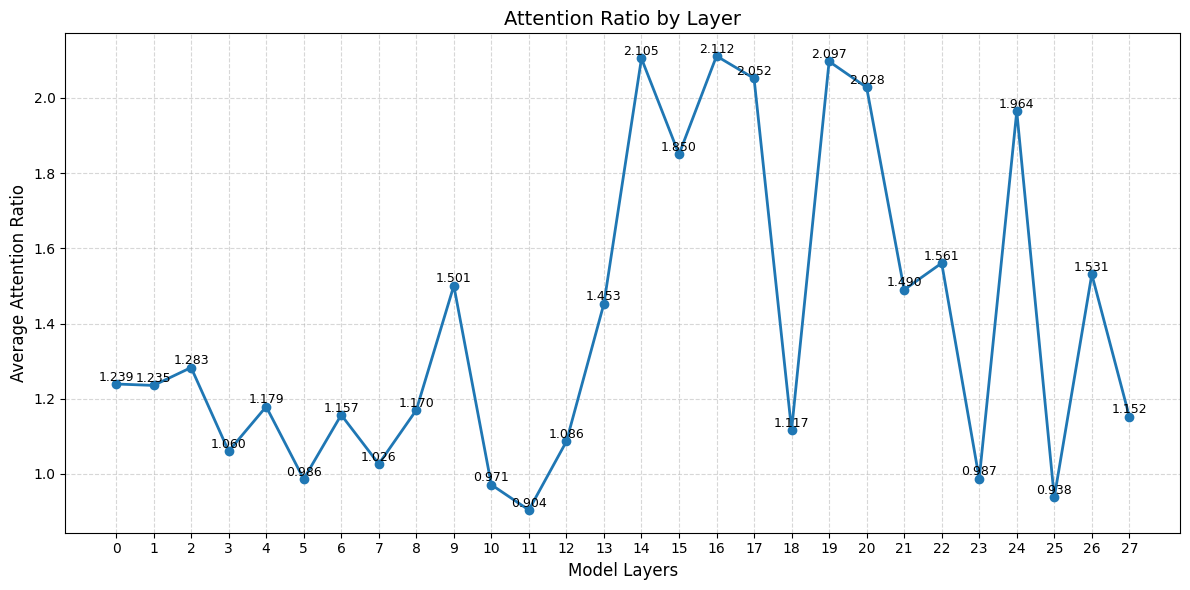

In [58]:
# Load bbox results for all modalities and compute average
bbox_modalities = ['ct', 'mr', 'pet', 'x_ray', 'fundus_photography', 'ultrasound', 'endoscopy', 'dermoscopy']
all_modalities_ratios = []

for modality in bbox_modalities:
    try:
        ratios = np.load(f"./results/head/bbox/attention_ratios_{modality}.npy")
        all_modalities_ratios.append(ratios)
    except FileNotFoundError:
        print(f"File not found for modality: {modality}")

# Compute average across all modalities
all_modalities_avg = np.concatenate(all_modalities_ratios).mean(axis=0)

plt.figure(figsize=(12, 6))
plt.plot(range(28), all_modalities_avg, marker='o', linewidth=2)

# Add data labels to each point
for x, y in zip(range(28), all_modalities_avg):
    plt.text(x, y+0.001, f"{y:.3f}", ha='center', va='bottom', fontsize=9)

# Titles and labels
plt.title("Attention Ratio by Layer", fontsize=14)
plt.xlabel("Model Layers", fontsize=12)
plt.ylabel("Average Attention Ratio", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.xticks(range(28))
plt.tight_layout()
plt.show()

##### KL Divergence

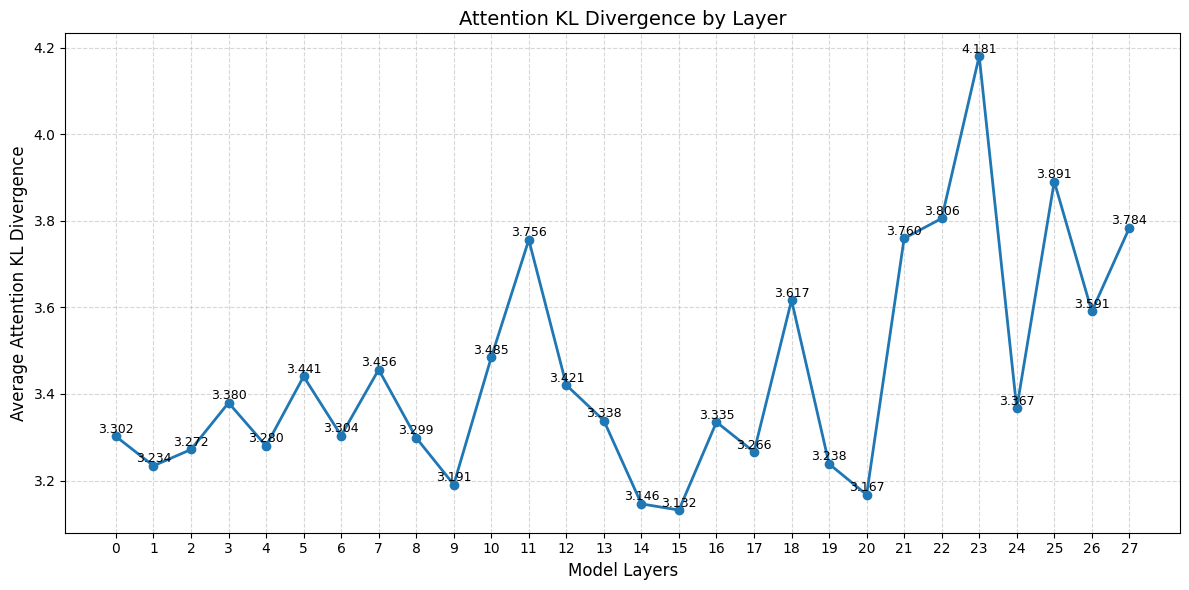

In [59]:
# Load bbox results for all modalities and compute average
bbox_modalities = ['ct', 'mr', 'pet', 'x_ray', 'fundus_photography', 'ultrasound', 'endoscopy', 'dermoscopy']
all_modalities_ratios = []

for modality in bbox_modalities:
    try:
        ratios = np.load(f"./results/head/bbox/attention_kl_{modality}.npy")
        all_modalities_ratios.append(ratios)
    except FileNotFoundError:
        print(f"File not found for modality: {modality}")

# Compute average across all modalities
all_modalities_avg = np.concatenate(all_modalities_ratios).mean(axis=0)

plt.figure(figsize=(12, 6))
plt.plot(range(28), all_modalities_avg, marker='o', linewidth=2)

# Add data labels to each point
for x, y in zip(range(28), all_modalities_avg):
    plt.text(x, y+0.001, f"{y:.3f}", ha='center', va='bottom', fontsize=9)

# Titles and labels
plt.title("Attention KL Divergence by Layer", fontsize=14)
plt.xlabel("Model Layers", fontsize=12)
plt.ylabel("Average Attention KL Divergence", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.xticks(range(28))
plt.tight_layout()
plt.show()

##### JS Divergence

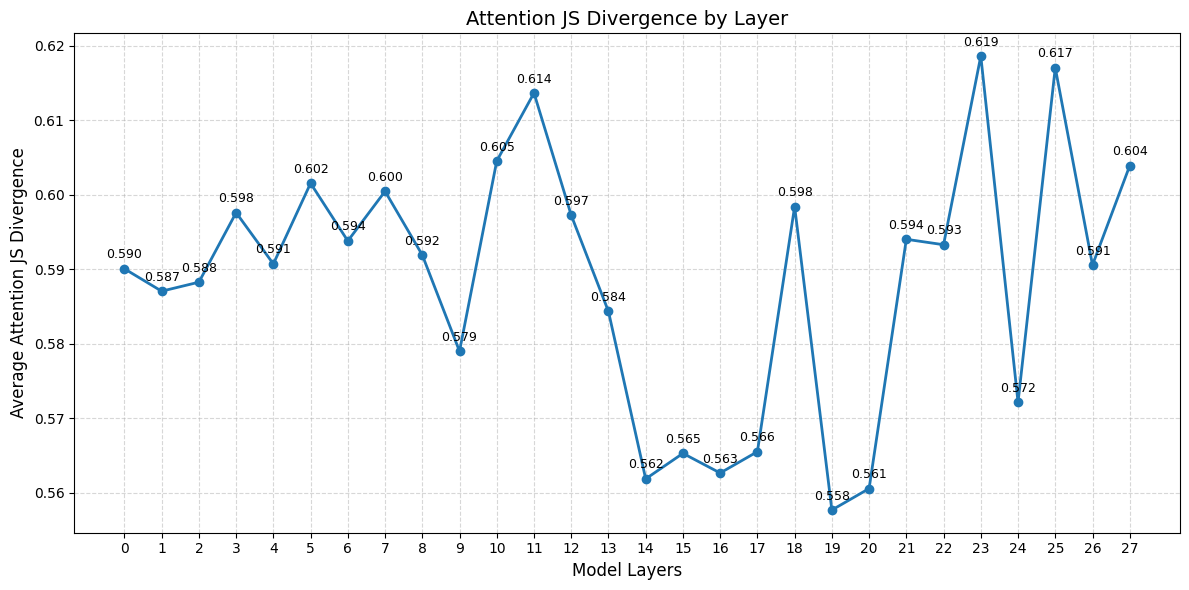

In [60]:
# Load bbox results for all modalities and compute average
bbox_modalities = ['ct', 'mr', 'pet', 'x_ray', 'fundus_photography', 'ultrasound', 'endoscopy', 'dermoscopy']
all_modalities_ratios = []

for modality in bbox_modalities:
    try:
        ratios = np.load(f"./results/head/bbox/attention_js_{modality}.npy")
        all_modalities_ratios.append(ratios)
    except FileNotFoundError:
        print(f"File not found for modality: {modality}")

# Compute average across all modalities
all_modalities_avg = np.concatenate(all_modalities_ratios).mean(axis=0)

plt.figure(figsize=(12, 6))
plt.plot(range(28), all_modalities_avg, marker='o', linewidth=2)

# Add data labels to each point
for x, y in zip(range(28), all_modalities_avg):
    plt.text(x, y+0.001, f"{y:.3f}", ha='center', va='bottom', fontsize=9)

# Titles and labels
plt.title("Attention JS Divergence by Layer", fontsize=14)
plt.xlabel("Model Layers", fontsize=12)
plt.ylabel("Average Attention JS Divergence", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.xticks(range(28))
plt.tight_layout()
plt.show()

### COCO

##### Attention Ratio

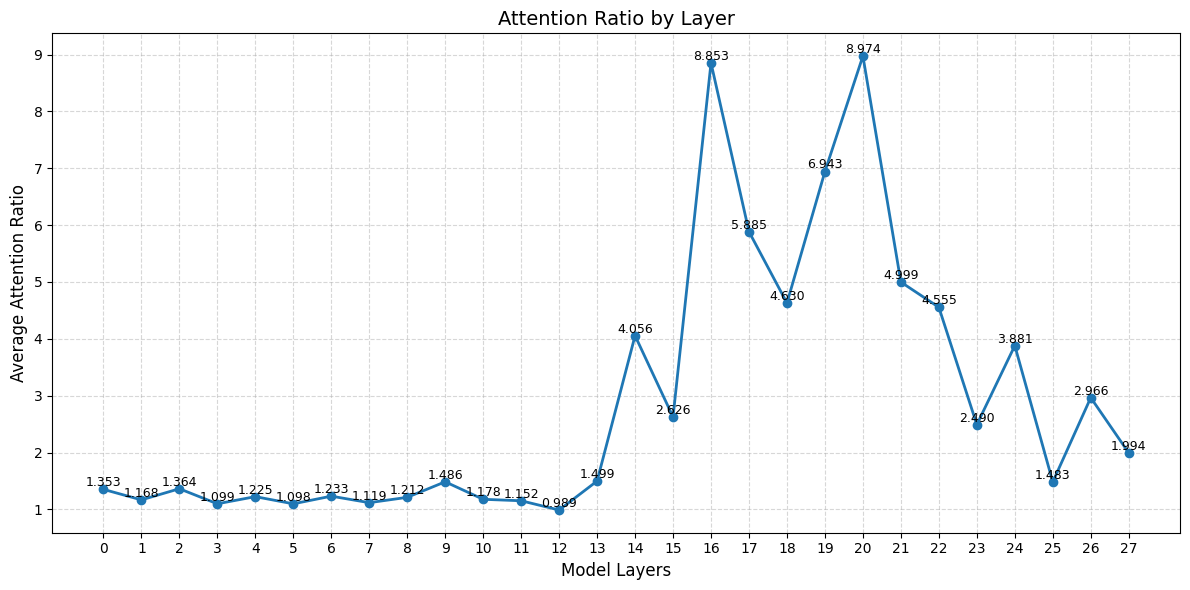

In [61]:
attention_ratios_normalized = np.load("./results/best_heads_coco/attention_ratios.npy")
layer_ratios = np.array(attention_ratios_normalized).mean(axis=0)

plt.figure(figsize=(12, 6))
plt.plot(range(28), layer_ratios, marker='o', linewidth=2)

# Add data labels to each point
for x, y in zip(range(28), layer_ratios):
    plt.text(x, y+0.001, f"{y:.3f}", ha='center', va='bottom', fontsize=9)

# Titles and labels
plt.title("Attention Ratio by Layer", fontsize=14)
plt.xlabel("Model Layers", fontsize=12)
plt.ylabel("Average Attention Ratio", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.xticks(range(28))
plt.tight_layout()
plt.show()

##### KL Divergence

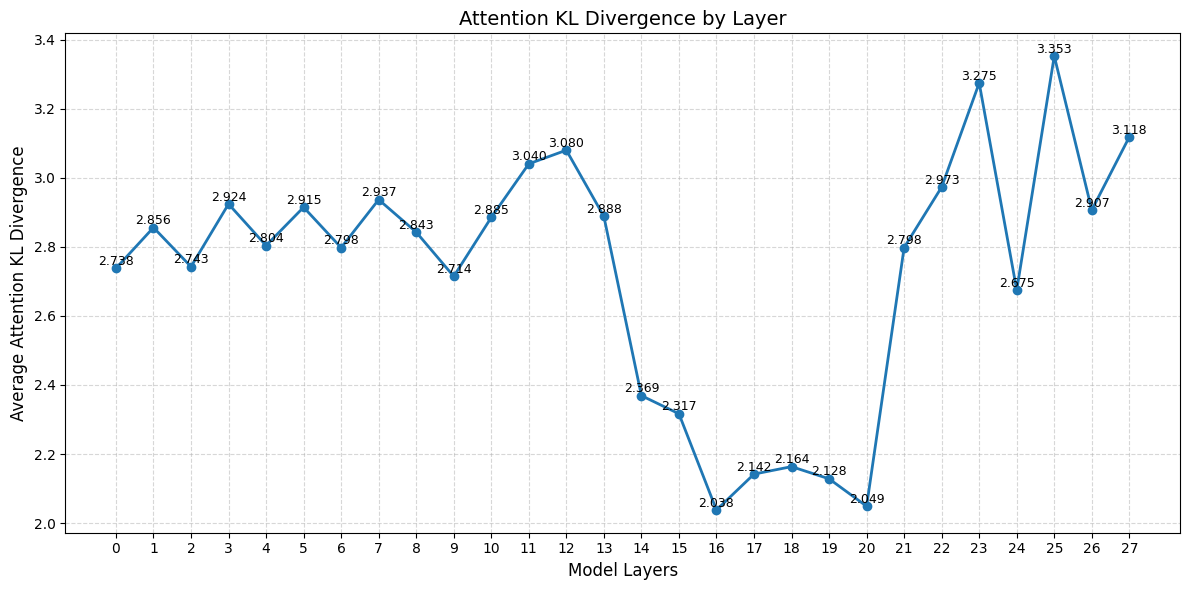

In [62]:
attention_kl_normalized = np.load("./results/best_heads_coco/attention_kl.npy")
layer_ratios = np.array(attention_kl_normalized).mean(axis=0)

plt.figure(figsize=(12, 6))
plt.plot(range(28), layer_ratios, marker='o', linewidth=2)

# Add data labels to each point
for x, y in zip(range(28), layer_ratios):
    plt.text(x, y+0.001, f"{y:.3f}", ha='center', va='bottom', fontsize=9)

# Titles and labels
plt.title("Attention KL Divergence by Layer", fontsize=14)
plt.xlabel("Model Layers", fontsize=12)
plt.ylabel("Average Attention KL Divergence", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.xticks(range(28))
plt.tight_layout()
plt.show()

##### JS Divergence

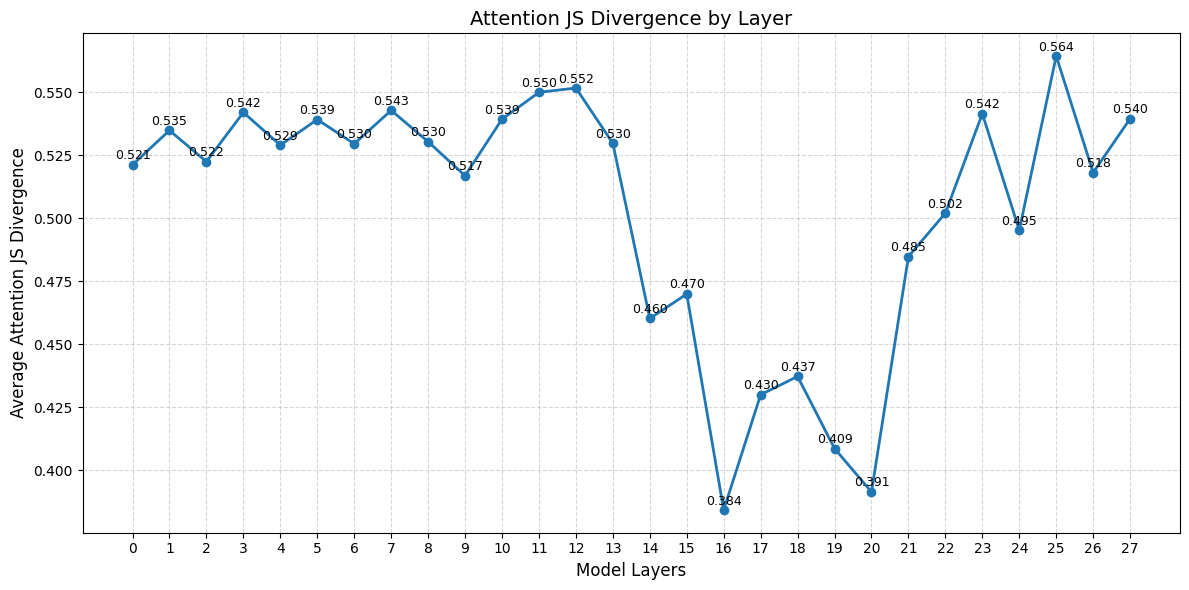

In [63]:
attention_js_normalized = np.load("./results/best_heads_coco/attention_js.npy")
layer_ratios = np.array(attention_js_normalized).mean(axis=0)

plt.figure(figsize=(12, 6))
plt.plot(range(28), layer_ratios, marker='o', linewidth=2)

# Add data labels to each point
for x, y in zip(range(28), layer_ratios):
    plt.text(x, y+0.001, f"{y:.3f}", ha='center', va='bottom', fontsize=9)

# Titles and labels
plt.title("Attention JS Divergence by Layer", fontsize=14)
plt.xlabel("Model Layers", fontsize=12)
plt.ylabel("Average Attention JS Divergence", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.xticks(range(28))
plt.tight_layout()
plt.show()


=== Processing with lowest 3 heads ===


Processing 3 heads: 100%|██████████| 4000/4000 [33:10<00:00,  2.01it/s]  


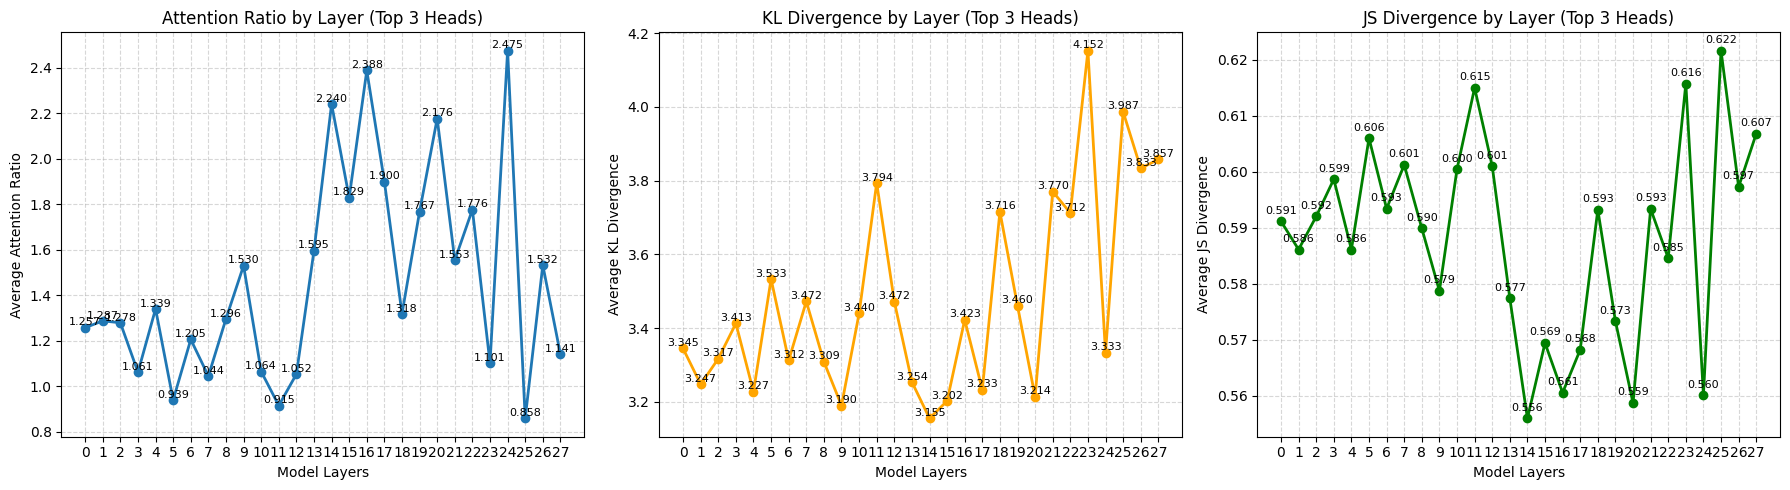


=== Processing with lowest 5 heads ===


Processing 5 heads: 100%|██████████| 4000/4000 [33:09<00:00,  2.01it/s]  


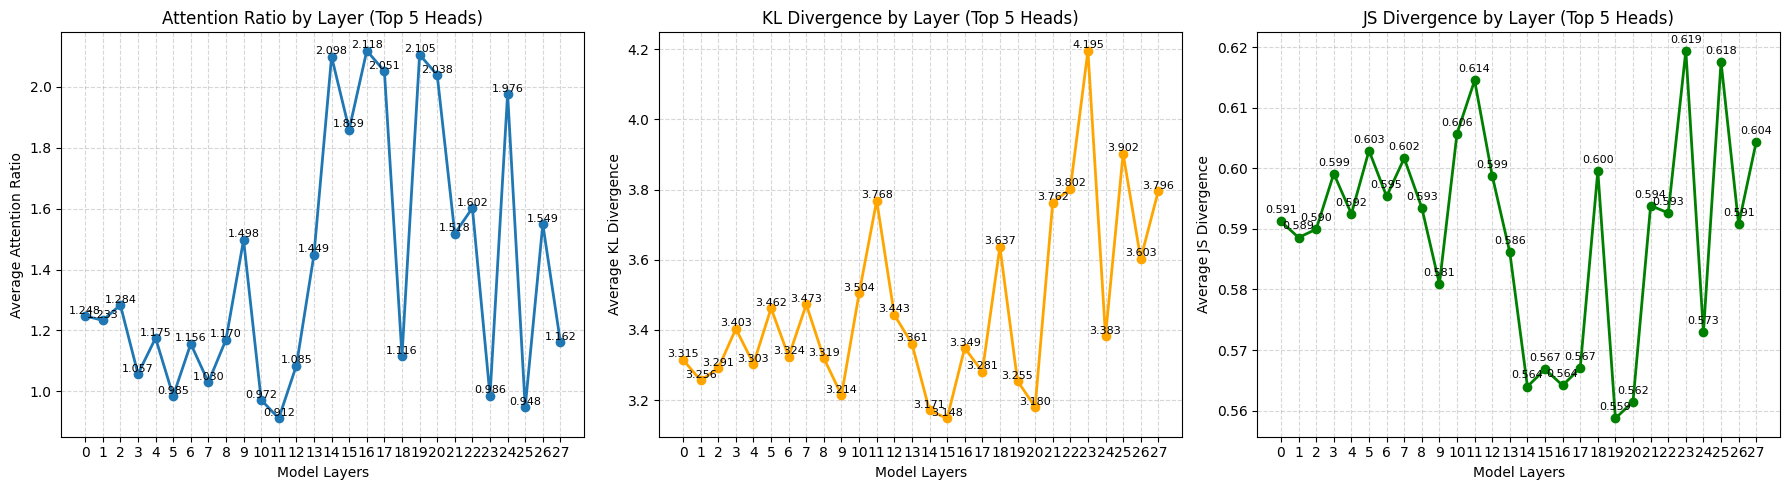


=== Processing with lowest 7 heads ===


Processing 7 heads: 100%|██████████| 4000/4000 [33:14<00:00,  2.01it/s]  


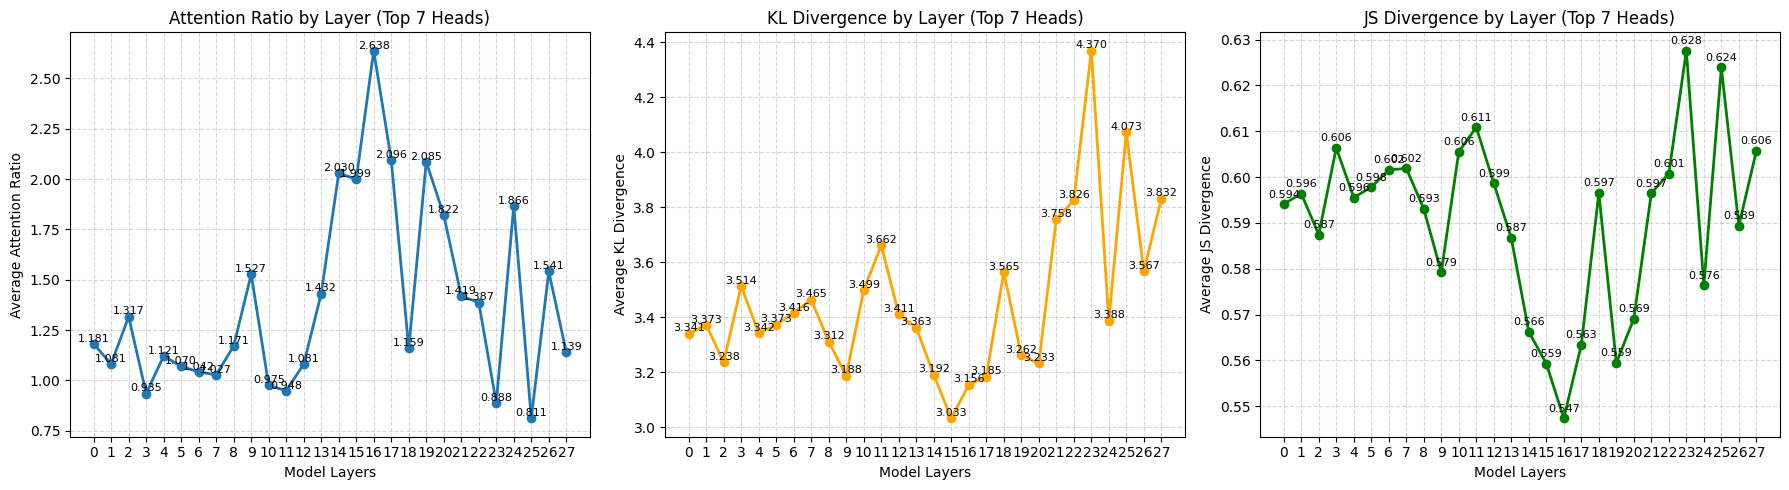


=== Processing with lowest 10 heads ===


Processing 10 heads: 100%|██████████| 4000/4000 [33:09<00:00,  2.01it/s]  


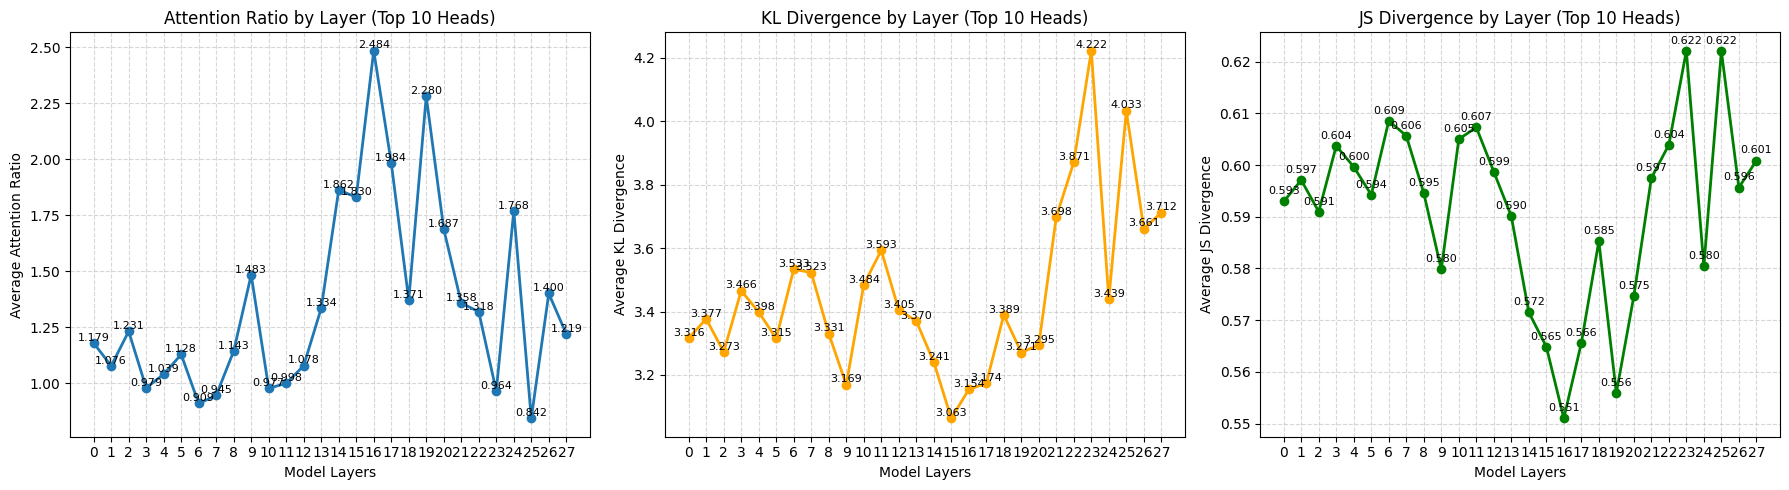

In [16]:
# Process for different numbers of lowest heads

questions = []
input_path = "./VGMED.jsonl"
data_path = "/media/tianze/cac0a3a7-7037-45fd-a689-d4179f2f883b/home/tianze/Datasets/SAMed2D_v1/selected"
with open(input_path, "r") as infile:
    for line in infile:
        questions.append(json.loads(line))

questions = random.sample(questions, 4000)


for num_heads in [3, 5, 7, 10]:
    print(f"\n=== Processing with lowest {num_heads} heads ===")
    
    attention_ratios_normalized = []
    attention_kl_normalized = []
    attention_js_normalized = []
    
    # Get the appropriate mask
    if num_heads == 3:
        mask = lowest_3_mask
    elif num_heads == 5:
        mask = lowest_5_mask
    elif num_heads == 7:
        mask = lowest_7_mask
    elif num_heads == 10:
        mask = lowest_10_mask
        
    
    for sample in tqdm(questions, desc=f"Processing {num_heads} heads"):
        image_path = os.path.join(data_path, sample["image"])
        qs = f"Is there a {sample['label']} in the image?"
        att_maps, general_att_maps = generate_attention_maps_per_head(qs, image_path)
        att_maps = att_maps * mask[:, :, np.newaxis]
        att_maps = att_maps.mean(axis=1)
        gt_tokens = sample["bbox_gt_tokens"]
        modality = sample["modality"]
        
        att_ratio_normalized = attention_ratio_vectorized(att_maps/general_att_maps, gt_tokens)
        att_kl_normalized = kl_divergence_vectorized(att_maps/general_att_maps, gt_tokens)
        att_js_normalized = js_divergence_vectorized(att_maps/general_att_maps, gt_tokens)
        
        attention_ratios_normalized.append(att_ratio_normalized)
        attention_kl_normalized.append(att_kl_normalized)
        attention_js_normalized.append(att_js_normalized)


    # Plot results for current num_heads setting
    layer_ratios = np.array(attention_ratios_normalized).mean(axis=0)
    layer_kl = np.array(attention_kl_normalized).mean(axis=0)
    layer_js = np.array(attention_js_normalized).mean(axis=0)
    
    # Create subplots for the three metrics
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Attention Ratio plot
    axes[0].plot(range(28), layer_ratios, marker='o', linewidth=2)
    for x, y in zip(range(28), layer_ratios):
        axes[0].text(x, y+0.001, f"{y:.3f}", ha='center', va='bottom', fontsize=8)
    axes[0].set_title(f"Attention Ratio by Layer (Top {num_heads} Heads)", fontsize=12)
    axes[0].set_xlabel("Model Layers", fontsize=10)
    axes[0].set_ylabel("Average Attention Ratio", fontsize=10)
    axes[0].grid(True, linestyle='--', alpha=0.5)
    axes[0].set_xticks(range(28))
    
    # KL Divergence plot
    axes[1].plot(range(28), layer_kl, marker='o', linewidth=2, color='orange')
    for x, y in zip(range(28), layer_kl):
        axes[1].text(x, y+0.001, f"{y:.3f}", ha='center', va='bottom', fontsize=8)
    axes[1].set_title(f"KL Divergence by Layer (Top {num_heads} Heads)", fontsize=12)
    axes[1].set_xlabel("Model Layers", fontsize=10)
    axes[1].set_ylabel("Average KL Divergence", fontsize=10)
    axes[1].grid(True, linestyle='--', alpha=0.5)
    axes[1].set_xticks(range(28))
    
    # JS Divergence plot
    axes[2].plot(range(28), layer_js, marker='o', linewidth=2, color='green')
    for x, y in zip(range(28), layer_js):
        axes[2].text(x, y+0.001, f"{y:.3f}", ha='center', va='bottom', fontsize=8)
    axes[2].set_title(f"JS Divergence by Layer (Top {num_heads} Heads)", fontsize=12)
    axes[2].set_xlabel("Model Layers", fontsize=10)
    axes[2].set_ylabel("Average JS Divergence", fontsize=10)
    axes[2].grid(True, linestyle='--', alpha=0.5)
    axes[2].set_xticks(range(28))
    
    plt.tight_layout()
    plt.show()


=== Processing with lowest 28 heads ===


Processing 28 heads: 100%|██████████| 4000/4000 [32:20<00:00,  2.06it/s]  


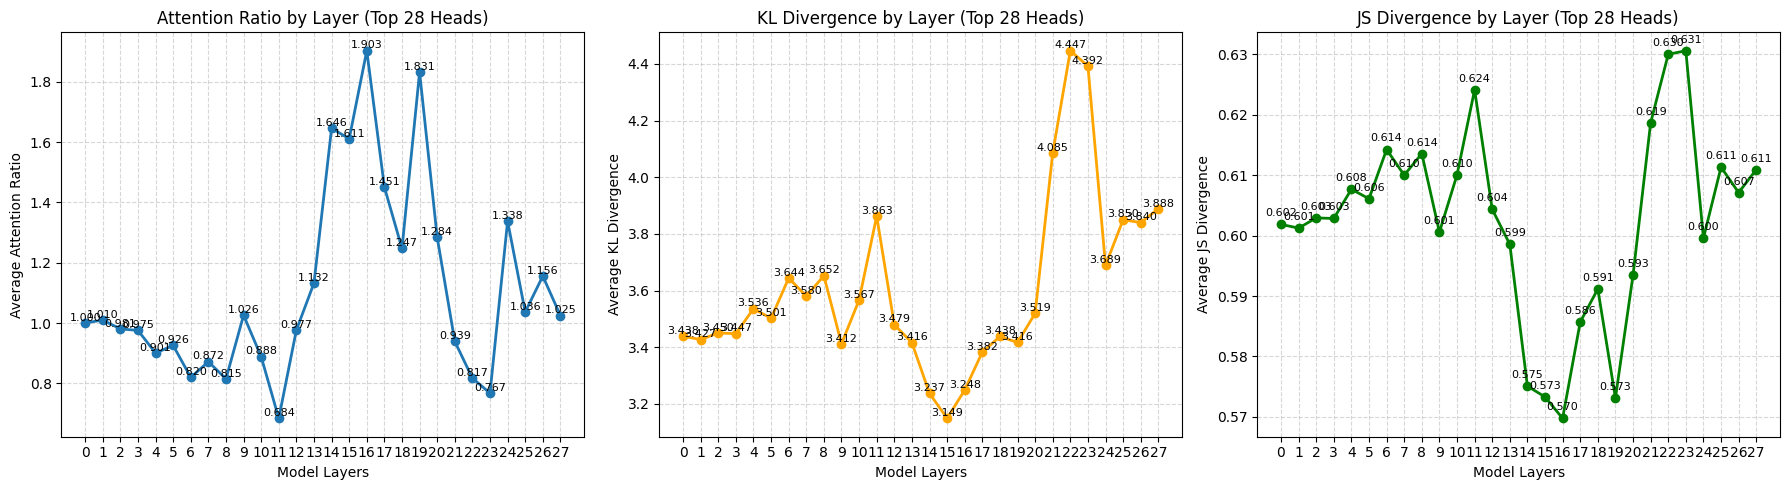

In [18]:
# Process for different numbers of lowest heads

questions = []
input_path = "./VGMED.jsonl"
data_path = "/media/tianze/cac0a3a7-7037-45fd-a689-d4179f2f883b/home/tianze/Datasets/SAMed2D_v1/selected"
with open(input_path, "r") as infile:
    for line in infile:
        questions.append(json.loads(line))

questions = random.sample(questions, 4000)

num_heads = 28

print(f"\n=== Processing with lowest {num_heads} heads ===")

attention_ratios_normalized = []
attention_kl_normalized = []
attention_js_normalized = []

mask = lowest_28_mask
    

for sample in tqdm(questions, desc=f"Processing {num_heads} heads"):
    image_path = os.path.join(data_path, sample["image"])
    qs = f"Is there a {sample['label']} in the image?"
    att_maps, general_att_maps = generate_attention_maps_per_head(qs, image_path)
    att_maps = att_maps * mask[:, :, np.newaxis]
    att_maps = att_maps.mean(axis=1)
    gt_tokens = sample["bbox_gt_tokens"]
    modality = sample["modality"]
    
    att_ratio_normalized = attention_ratio_vectorized(att_maps/general_att_maps, gt_tokens)
    att_kl_normalized = kl_divergence_vectorized(att_maps/general_att_maps, gt_tokens)
    att_js_normalized = js_divergence_vectorized(att_maps/general_att_maps, gt_tokens)
    
    attention_ratios_normalized.append(att_ratio_normalized)
    attention_kl_normalized.append(att_kl_normalized)
    attention_js_normalized.append(att_js_normalized)


# Plot results for current num_heads setting
layer_ratios = np.array(attention_ratios_normalized).mean(axis=0)
layer_kl = np.array(attention_kl_normalized).mean(axis=0)
layer_js = np.array(attention_js_normalized).mean(axis=0)

# Create subplots for the three metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Attention Ratio plot
axes[0].plot(range(28), layer_ratios, marker='o', linewidth=2)
for x, y in zip(range(28), layer_ratios):
    axes[0].text(x, y+0.001, f"{y:.3f}", ha='center', va='bottom', fontsize=8)
axes[0].set_title(f"Attention Ratio by Layer (Top {num_heads} Heads)", fontsize=12)
axes[0].set_xlabel("Model Layers", fontsize=10)
axes[0].set_ylabel("Average Attention Ratio", fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].set_xticks(range(28))

# KL Divergence plot
axes[1].plot(range(28), layer_kl, marker='o', linewidth=2, color='orange')
for x, y in zip(range(28), layer_kl):
    axes[1].text(x, y+0.001, f"{y:.3f}", ha='center', va='bottom', fontsize=8)
axes[1].set_title(f"KL Divergence by Layer (Top {num_heads} Heads)", fontsize=12)
axes[1].set_xlabel("Model Layers", fontsize=10)
axes[1].set_ylabel("Average KL Divergence", fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].set_xticks(range(28))

# JS Divergence plot
axes[2].plot(range(28), layer_js, marker='o', linewidth=2, color='green')
for x, y in zip(range(28), layer_js):
    axes[2].text(x, y+0.001, f"{y:.3f}", ha='center', va='bottom', fontsize=8)
axes[2].set_title(f"JS Divergence by Layer (Top {num_heads} Heads)", fontsize=12)
axes[2].set_xlabel("Model Layers", fontsize=10)
axes[2].set_ylabel("Average JS Divergence", fontsize=10)
axes[2].grid(True, linestyle='--', alpha=0.5)
axes[2].set_xticks(range(28))

plt.tight_layout()
plt.show()

# Measure attention metrics

### VGMED

##### Attention Ratio

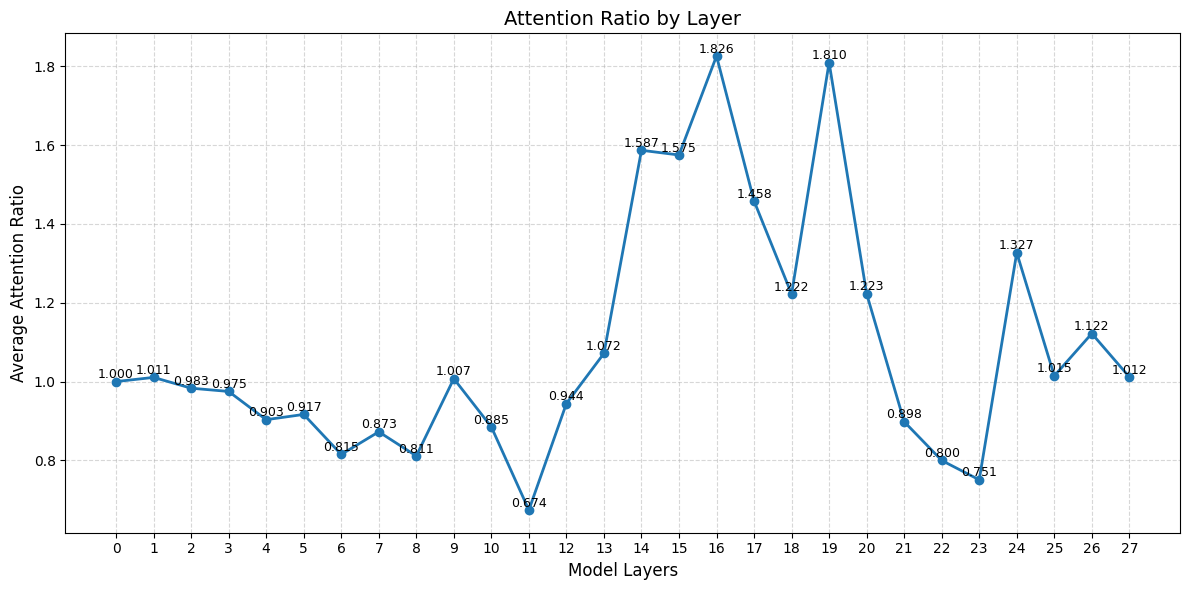

In [2]:
attention_ratios_normalized = np.load("./results/7B/layer_VGMED/localization/attention_ratios.npy")
layer_ratios = np.array(attention_ratios_normalized).mean(axis=0)

plt.figure(figsize=(12, 6))
plt.plot(range(LAYERS), layer_ratios, marker='o', linewidth=2)

# Add data labels to each point
for x, y in zip(range(LAYERS), layer_ratios):
    plt.text(x, y+0.001, f"{y:.3f}", ha='center', va='bottom', fontsize=9)

# Titles and labels
plt.title("Attention Ratio by Layer", fontsize=14)
plt.xlabel("Model Layers", fontsize=12)
plt.ylabel("Average Attention Ratio", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.xticks(range(LAYERS))
plt.tight_layout()
plt.show()

##### KL Divergence

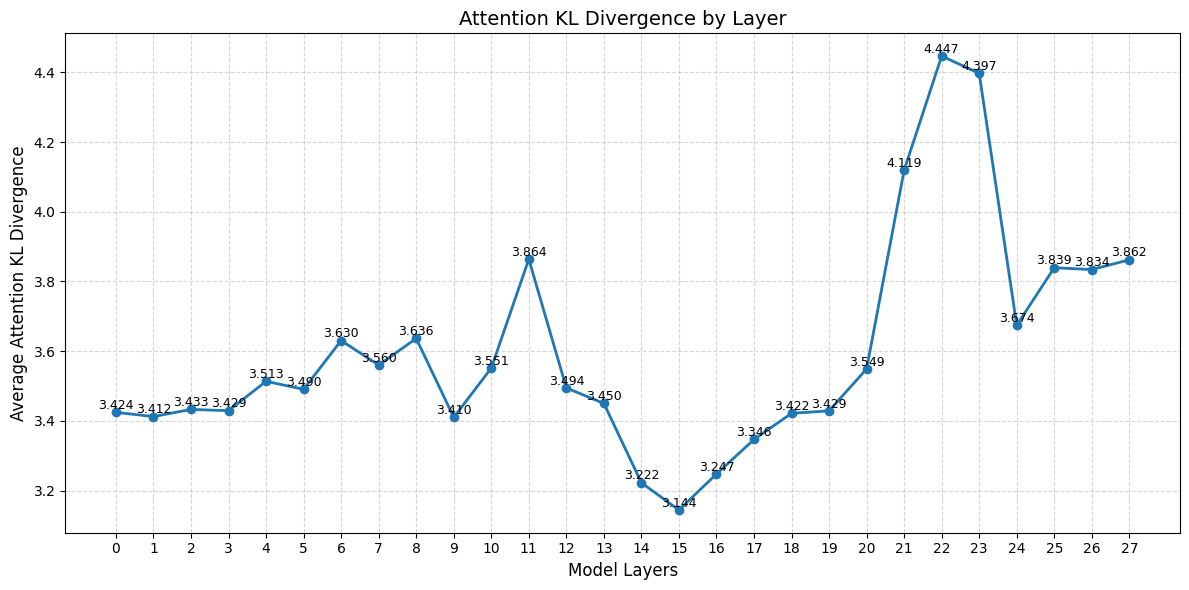

In [3]:
attention_kl_normalized = np.load("./results/7B/layer_VGMED/localization/attention_kl.npy")
layer_ratios = np.array(attention_kl_normalized).mean(axis=0)

plt.figure(figsize=(12, 6))
plt.plot(range(LAYERS), layer_ratios, marker='o', linewidth=2)

# Add data labels to each point
for x, y in zip(range(LAYERS), layer_ratios):
    plt.text(x, y+0.001, f"{y:.3f}", ha='center', va='bottom', fontsize=9)

# Titles and labels
plt.title("Attention KL Divergence by Layer", fontsize=14)
plt.xlabel("Model Layers", fontsize=12)
plt.ylabel("Average Attention KL Divergence", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.xticks(range(LAYERS))
plt.tight_layout()
plt.show()

##### JS Divergence

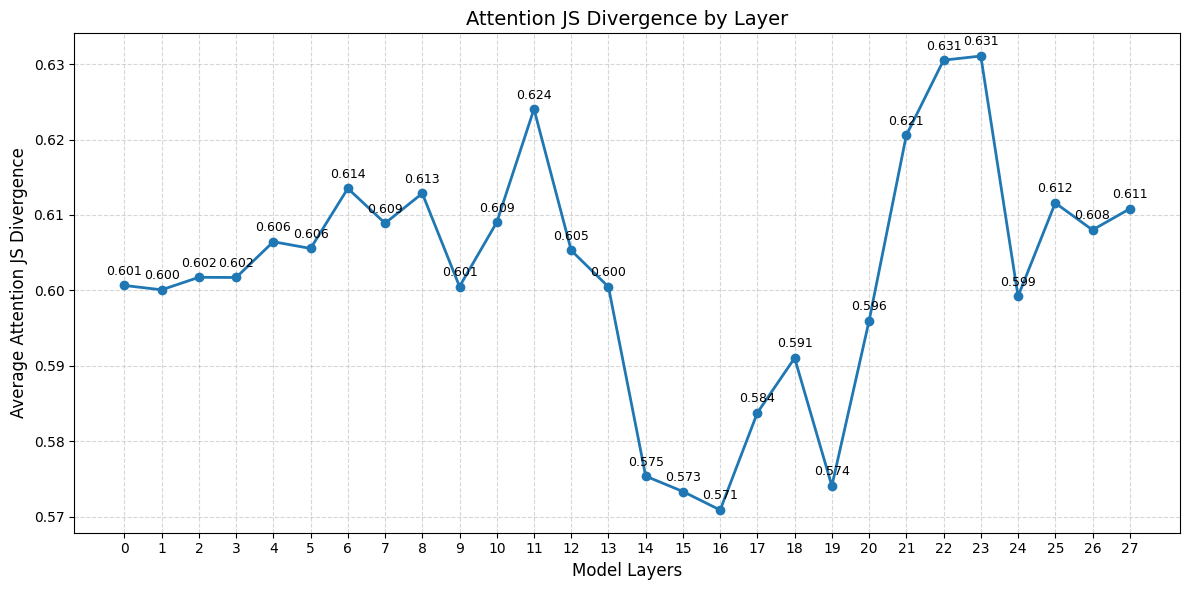

In [4]:
attention_js_normalized = np.load("./results/7B/layer_VGMED/localization/attention_js.npy")
layer_ratios = np.array(attention_js_normalized).mean(axis=0)

plt.figure(figsize=(12, 6))
plt.plot(range(LAYERS), layer_ratios, marker='o', linewidth=2)

# Add data labels to each point
for x, y in zip(range(LAYERS), layer_ratios):
    plt.text(x, y+0.001, f"{y:.3f}", ha='center', va='bottom', fontsize=9)

# Titles and labels
plt.title("Attention JS Divergence by Layer", fontsize=14)
plt.xlabel("Model Layers", fontsize=12)
plt.ylabel("Average Attention JS Divergence", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.xticks(range(LAYERS))
plt.tight_layout()
plt.show()

### COCO Localization

In [4]:
attention_ratios_normalized = []
attention_kl_normalized = []
attention_js_normalized = []

questions = []
input_path = "./COCO_localization.jsonl"
data_path = "/home/tianze/MLLM/HuatuoGPT-Vision/val2014"
with open(input_path, "r") as infile:
    for line in infile:
        questions.append(json.loads(line))


for sample in tqdm(questions):
    image_path = os.path.join(data_path, sample["image"])
    qs = sample["question"]
    gt_tokens = sample["gt_tokens"]
    att_maps, general_att_maps = generate_attention_maps(qs, image_path)

    # att_ratio_normalized = attention_ratio_vectorized(att_maps/general_att_maps, gt_tokens)
    # att_kl_normalized = kl_divergence_vectorized(att_maps/general_att_maps, gt_tokens)
    # att_js_normalized = js_divergence_vectorized(att_maps/general_att_maps, gt_tokens)

    # attention_ratios_normalized.append(att_ratio_normalized)
    # attention_kl_normalized.append(att_kl_normalized)
    # attention_js_normalized.append(att_js_normalized)


# os.makedirs("./results/layer_coco/", exist_ok=True)
# np.save(f"./results/layer_coco/attention_ratios.npy", np.array(attention_ratios_normalized))
# np.save(f"./results/layer_coco/attention_kl.npy", np.array(attention_kl_normalized))
# np.save(f"./results/layer_coco/attention_js.npy", np.array(attention_js_normalized))

  0%|          | 13/11468 [00:05<1:26:34,  2.21it/s]


KeyboardInterrupt: 

##### Attention Ratio

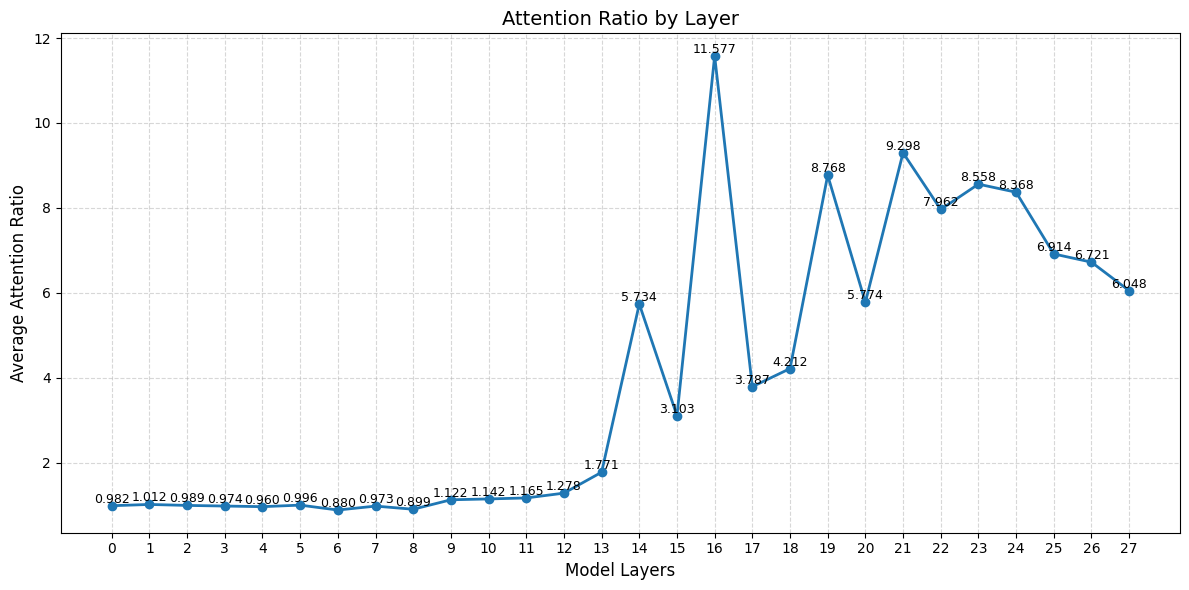

In [5]:
attention_ratios_normalized = np.load("./results/7B/layer_COCO/attribute/attention_ratios.npy")
layer_ratios = np.array(attention_ratios_normalized).mean(axis=0)

plt.figure(figsize=(12, 6))
plt.plot(range(LAYERS), layer_ratios, marker='o', linewidth=2)

# Add data labels to each point
for x, y in zip(range(LAYERS), layer_ratios):
    plt.text(x, y+0.001, f"{y:.3f}", ha='center', va='bottom', fontsize=9)

# Titles and labels
plt.title("Attention Ratio by Layer", fontsize=14)
plt.xlabel("Model Layers", fontsize=12)
plt.ylabel("Average Attention Ratio", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.xticks(range(LAYERS))
plt.tight_layout()
plt.show()

##### KL Divergence

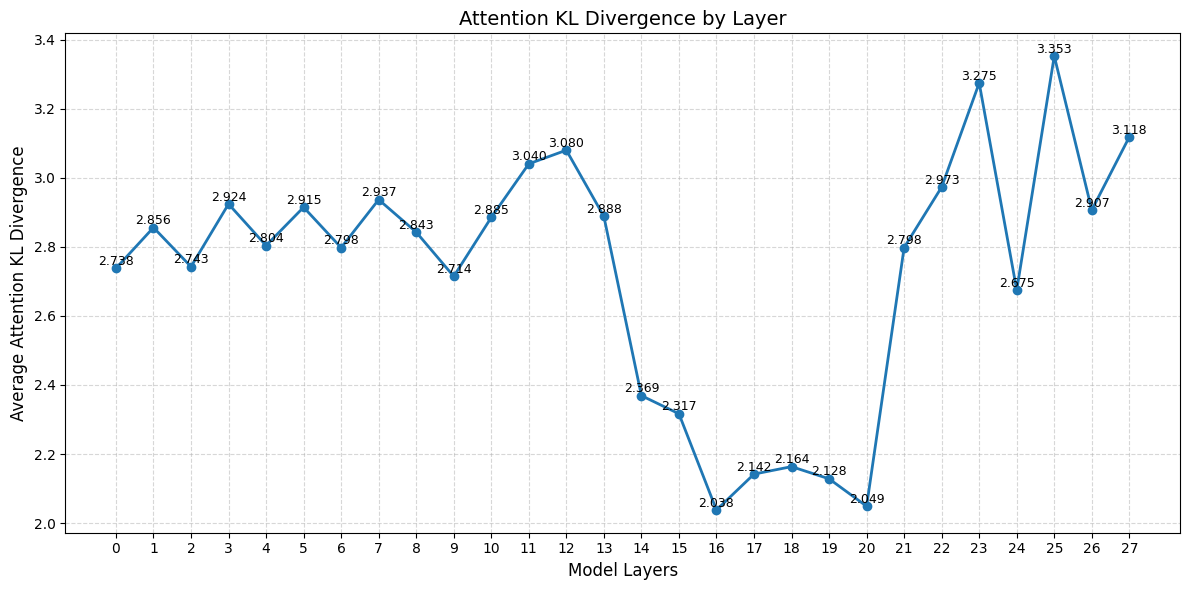

In [ ]:
attention_kl_normalized = np.load("./results/best_heads_coco/attention_kl.npy")
layer_ratios = np.array(attention_kl_normalized).mean(axis=0)

plt.figure(figsize=(12, 6))
plt.plot(range(28), layer_ratios, marker='o', linewidth=2)

# Add data labels to each point
for x, y in zip(range(28), layer_ratios):
    plt.text(x, y+0.001, f"{y:.3f}", ha='center', va='bottom', fontsize=9)

# Titles and labels
plt.title("Attention KL Divergence by Layer", fontsize=14)
plt.xlabel("Model Layers", fontsize=12)
plt.ylabel("Average Attention KL Divergence", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.xticks(range(28))
plt.tight_layout()
plt.show()

##### JS Divergence

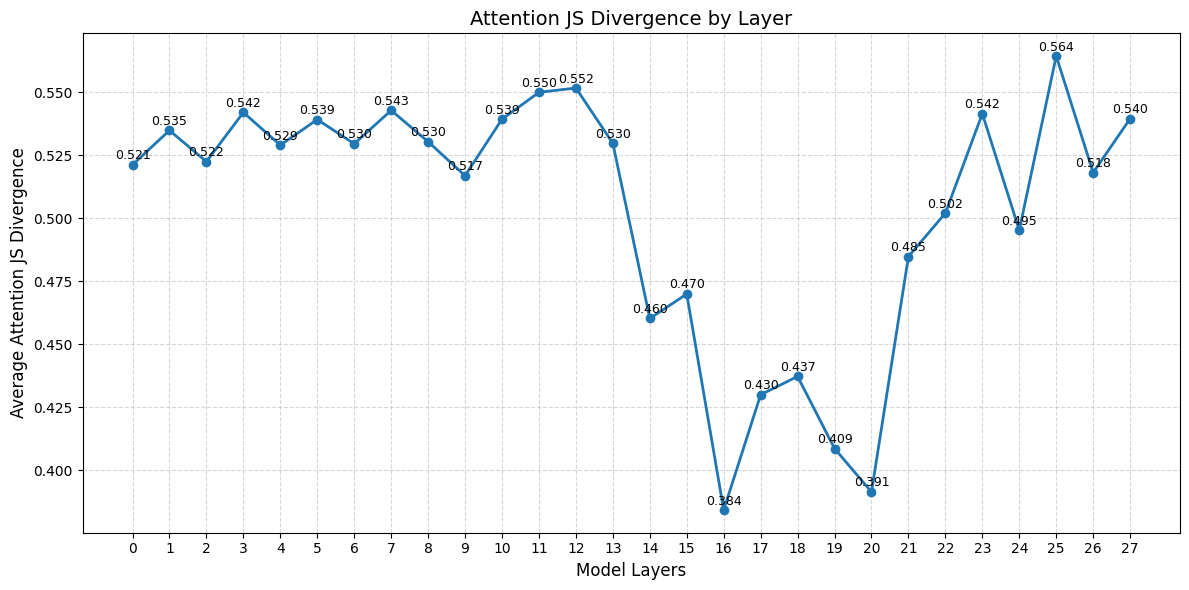

In [ ]:
attention_js_normalized = np.load("./results/best_heads_coco/attention_js.npy")
layer_ratios = np.array(attention_js_normalized).mean(axis=0)

plt.figure(figsize=(12, 6))
plt.plot(range(28), layer_ratios, marker='o', linewidth=2)

# Add data labels to each point
for x, y in zip(range(28), layer_ratios):
    plt.text(x, y+0.001, f"{y:.3f}", ha='center', va='bottom', fontsize=9)

# Titles and labels
plt.title("Attention JS Divergence by Layer", fontsize=14)
plt.xlabel("Model Layers", fontsize=12)
plt.ylabel("Average Attention JS Divergence", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.xticks(range(28))
plt.tight_layout()
plt.show()